<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Import et exploration DVF</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook constitue la première étape opérationnelle du pipeline analytique. Il centralise l’import des données DVF, les premiers contrôles de structure et les analyses exploratoires destinées à qualifier la qualité, la volumétrie et la cohérence des données immobilières exploitées dans les étapes suivantes.</p>
</div>

In [1]:
# Import des bibliothèques nécessaires à la préparation des données DVF.
# Le périmètre est volontairement restreint pour préserver la lisibilité et la reproductibilité du notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("✓ Imports réussis")


✓ Imports réussis


In [2]:
# Construction de chemins relatifs afin de garantir l'exécution du notebook depuis différents contextes.
# Cette approche évite la dépendance à des chemins absolus spécifiques à un poste.
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Définition des répertoires structurants du projet.
DATA_DIR = PROJECT_ROOT / "data"
DOCS_DIR = PROJECT_ROOT / "docs"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SRC_DIR = PROJECT_ROOT / "src"

RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Définition des chemins d'entrée/sortie canoniques du notebook.
# Le fichier d'entrée reste la source DVF brute ; les fichiers de sortie sont écrasés à chaque exécution.
INPUT_PATH = RAW_DIR / "dvf.csv"
OUTPUT_PATH = PROCESSED_DIR / "df_dvf_base_eco_intermediaire.parquet"
SAMPLE_OUTPUT_PATH = PROCESSED_DIR / "df_dvf_base_eco_intermediaire_sample.csv"

# Fichier historique à rapatrier si l'on ne souhaite pas rejouer le notebook.
# Ancien nom observé dans la version précédente du pipeline.
MIGRATION_SOURCE_CANDIDATE = PROCESSED_DIR / "dvf_base_eco_intermediaire.parquet"

print("CURRENT_DIR  :", CURRENT_DIR)
print("PROJECT_ROOT :", PROJECT_ROOT)
print("INPUT_PATH   :", INPUT_PATH)
print("INPUT existe :", INPUT_PATH.exists())
print("OUTPUT_PATH  :", OUTPUT_PATH)
print("SAMPLE_PATH  :", SAMPLE_OUTPUT_PATH)

print("\nVérification des répertoires cibles :")
for name, path in [
    ("data", DATA_DIR),
    ("docs", DOCS_DIR),
    ("outputs", OUTPUTS_DIR),
    ("src", SRC_DIR),
    ("data/processed", PROCESSED_DIR),
]:
    print(f"  - {name:14s}: {path.exists()} -> {path}")

print("\nFichier historique à rapatrier si disponible :")
print(f"  - {MIGRATION_SOURCE_CANDIDATE} | existe : {MIGRATION_SOURCE_CANDIDATE.exists()}")


CURRENT_DIR  : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\notebooks
PROJECT_ROOT : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
INPUT_PATH   : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\raw\dvf.csv
INPUT existe : True
OUTPUT_PATH  : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_dvf_base_eco_intermediaire.parquet
SAMPLE_PATH  : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_dvf_base_eco_intermediaire_sample.csv

Vérification des répertoires cibles :
  - data          : True -> C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data
  - docs          : True -> C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\docs
  - outputs       : True -> C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs
  - src           : True -> C:\Users\club_\OneDrive\13_DOCUMENT\SYST

In [3]:
# Lecture initiale de la source DVF sans transformation métier.
# Cette étape documente l'état brut de la donnée en entrée du pipeline.
df_raw = pd.read_csv(INPUT_PATH, sep=",", decimal=",")

print("✓ DVF chargé")
print("Dimensions df_raw :", df_raw.shape)
print("\nPremières lignes :")
df_raw.head()

✓ DVF chargé
Dimensions df_raw : (20382915, 40)

Premières lignes :


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2021-1,2021-01-05,1,Vente,185000,5080.0,NaN,CHE DE VOGELAS,0471,1370.0,1426,Val-Revermont,1,NaN,NaN,01426312ZC0122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
1,2021-1,2021-01-05,1,Vente,185000,5080.0,NaN,CHE DE VOGELAS,0471,1370.0,1426,Val-Revermont,1,NaN,NaN,01426312ZC0122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,97.0,5.0,S,sols,NaN,NaN,2410.0,5.386107,46.327101
2,2021-2,2021-01-06,1,Vente,10,NaN,NaN,ROUGEMONT,B043,1290.0,1042,Bey,1,NaN,NaN,010420000A0204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,530.0,4.844318,46.224242
3,2021-3,2021-01-04,1,Vente,204332,7.0,NaN,ALL DES ECUREUILS,0276,1310.0,1065,Buellas,1,NaN,NaN,010650000B1325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,88.0,4.0,S,sols,NaN,NaN,866.0,5.157674,46.201035
4,2021-4,2021-01-06,1,Vente,320000,87.0,NaN,RTE DE CERTINES,0140,1250.0,1254,Montagnat,1,NaN,NaN,01254000AZ0011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,S,sols,NaN,NaN,1426.0,5.273214,46.15632


In [4]:
# Diagnostic structurel initial : types, volumétrie et complétude.
# Ce contrôle permet d'identifier les conversions nécessaires avant analyse économique.
print("=== Audit DVF - Info ===")
df_raw.info()


=== Audit DVF - Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20382915 entries, 0 to 20382914
Data columns (total 40 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   id_mutation                   object 
 1   date_mutation                 object 
 2   numero_disposition            int64  
 3   nature_mutation               object 
 4   valeur_fonciere               object 
 5   adresse_numero                float64
 6   adresse_suffixe               object 
 7   adresse_nom_voie              object 
 8   adresse_code_voie             object 
 9   code_postal                   float64
 10  code_commune                  object 
 11  nom_commune                   object 
 12  code_departement              object 
 13  ancien_code_commune           float64
 14  ancien_nom_commune            object 
 15  id_parcelle                   object 
 16  ancien_id_parcelle            object 
 17  numero_volume                 object 


In [5]:
# Recensement exhaustif des variables disponibles dans la source DVF.
# Cette vue sert de base à la sélection raisonnée des colonnes utiles.
print("=== Colonnes DVF ===")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:2d}. {col}")


=== Colonnes DVF ===
 1. id_mutation
 2. date_mutation
 3. numero_disposition
 4. nature_mutation
 5. valeur_fonciere
 6. adresse_numero
 7. adresse_suffixe
 8. adresse_nom_voie
 9. adresse_code_voie
10. code_postal
11. code_commune
12. nom_commune
13. code_departement
14. ancien_code_commune
15. ancien_nom_commune
16. id_parcelle
17. ancien_id_parcelle
18. numero_volume
19. lot1_numero
20. lot1_surface_carrez
21. lot2_numero
22. lot2_surface_carrez
23. lot3_numero
24. lot3_surface_carrez
25. lot4_numero
26. lot4_surface_carrez
27. lot5_numero
28. lot5_surface_carrez
29. nombre_lots
30. code_type_local
31. type_local
32. surface_reelle_bati
33. nombre_pieces_principales
34. code_nature_culture
35. nature_culture
36. code_nature_culture_speciale
37. nature_culture_speciale
38. surface_terrain
39. longitude
40. latitude


In [ ]:
# Fonctions utilitaires transverses du notebook.
# Ces fonctions servent à standardiser plusieurs opérations répétitives :
# - le suivi des volumes de données,
# - les contrôles rapides de variables catégorielles,
# - la préparation des données avant visualisation.
# L'objectif est de rendre les contrôles plus homogènes,
# plus lisibles et plus faciles à réutiliser dans tout le notebook.


def show_counts(df, label):
    """
    Affiche les principaux volumes d'une table.

    Cette fonction permet de suivre l'évolution des données
    au fil des étapes de préparation :
    - nombre total de lignes,
    - nombre de mutations immobilières uniques.

    Le suivi volumétrique est important pour mesurer
    l'impact des filtres et transformations appliqués.
    """
    print(f"=== {label} ===")
    print(f"Lignes      : {len(df):,}")
    print(f"Mutations   : {df['id_mutation'].nunique():,}")


def quick_freq(df, col, n=15):
    """
    Affiche rapidement les modalités dominantes
    d'une variable catégorielle.

    Cette fonction permet de :
    - identifier les catégories principales,
    - repérer des valeurs rares ou atypiques,
    - contrôler la cohérence des transformations.

    Paramètres :
    - df : DataFrame analysé
    - col : colonne catégorielle étudiée
    - n : nombre maximum de modalités affichées
    """
    print(f"=== {col} ===")
    print(f"Nb modalites : {df[col].nunique(dropna=False):,}")
    print(df[col].value_counts(dropna=False).head(n))


def sanitize_for_plot(df, x=None, y=None, hue=None):
    """
    Prépare un jeu de données avant visualisation.

    Les bibliothèques de visualisation supportent parfois mal
    les valeurs manquantes sur les variables utilisées dans le graphique.
    Cette fonction :
    - identifie les colonnes nécessaires au tracé,
    - supprime uniquement les lignes incomplètes
      sur ces colonnes,
    - retourne une copie propre du DataFrame.

    Paramètres :
    - x : variable de l'axe horizontal
    - y : variable de l'axe vertical
    - hue : variable de coloration / segmentation
    """

    # Liste des colonnes réellement utilisées dans le graphique.
    # Les paramètres non renseignés (None) sont ignorés.
    cols = [c for c in [x, y, hue] if c is not None]

    # Si des colonnes sont spécifiées :
    # suppression des lignes contenant des valeurs manquantes
    # sur ces variables uniquement.
    # Sinon, retourne simplement une copie du DataFrame.
    return df.dropna(subset=cols).copy() if cols else df.copy()


# Confirmation de la disponibilité des fonctions utilitaires.
# Ce rappel facilite la lecture du notebook
# et documente les outils transverses disponibles.
print("✓ Fonctions utilitaires definies :")
print("  - show_counts : suivi volumetrique des tables")
print("  - quick_freq : controle rapide des modalites")
print("  - sanitize_for_plot : securisation des donnees de visualisation")


✓ Fonctions utilitaires definies :
  - show_counts : suivi volumetrique des tables
  - quick_freq : controle rapide des modalites
  - sanitize_for_plot : securisation des donnees de visualisation


In [ ]:
# Creation d'une copie de travail afin de conserver une reference brute traçable.
df_audit = df_raw.copy()

# Creation de la variable carrez_cols en vue de leur conversion numerique
carrez_cols = [
    "lot1_surface_carrez", "lot2_surface_carrez", "lot3_surface_carrez",
    "lot4_surface_carrez", "lot5_surface_carrez",
]
geo_cols = ["longitude", "latitude"]

# Conversion de la date pour permettre les controles temporels et les agregations ulterieures.
df_audit["date_mutation"] = pd.to_datetime(df_audit["date_mutation"], errors="coerce")

# Conversion des nombres : gestion des virgules, valeurs vides et entrees non conformes.
def to_float_fr(series):
    return pd.to_numeric(
        series.astype(str)
              .str.strip()
              .replace({"": float("nan"), "nan": float("nan"), "None": float("nan")})
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Conversion des variables monetaires et surfaciques avant tout calcul de ratio.
df_audit["valeur_fonciere"] = to_float_fr(df_audit["valeur_fonciere"])
for col in carrez_cols:
    df_audit[col] = to_float_fr(df_audit[col])
for col in geo_cols:
    df_audit[col] = to_float_fr(df_audit[col])

# Conversion complementaire des autres variables numeriques structurantes.
numeric_cols = [
    "surface_reelle_bati", "surface_terrain", "nombre_pieces_principales",
    "nombre_lots"
]
for col in numeric_cols:
    df_audit[col] = to_float_fr(df_audit[col])

# Verification minimale de coherence des types apres transformation.
cols_check = ["date_mutation", "valeur_fonciere"] + carrez_cols + geo_cols
print("OK Conversions numeriques effectuees")
print("\nTypes apres conversion :")
print(df_audit[cols_check].dtypes)

OK Conversions numeriques effectuees

Types apres conversion :
date_mutation          datetime64[ns]
valeur_fonciere               float64
lot1_surface_carrez           float64
lot2_surface_carrez           float64
lot3_surface_carrez           float64
lot4_surface_carrez           float64
lot5_surface_carrez           float64
longitude                     float64
latitude                      float64
dtype: object


In [9]:
# Sélection des variables descriptives des biens objet des mutations.
COLS_MUTATION = [
    "id_mutation", "date_mutation", "numero_disposition",
    "nature_mutation", "valeur_fonciere"
]

COLS_GEO = [
    "code_commune", "nom_commune", "code_departement",
    "longitude", "latitude"
]

COLS_CARREZ = [
    "lot1_surface_carrez", "lot2_surface_carrez", "lot3_surface_carrez",
    "lot4_surface_carrez", "lot5_surface_carrez", "nombre_lots"
]

COLS_BIEN = [
    "type_local", "surface_reelle_bati",
    "nombre_pieces_principales", "surface_terrain"
]

COLS_FONCIER = [
    "id_parcelle", "code_nature_culture", "nature_culture",
    "code_nature_culture_speciale", "nature_culture_speciale"
]

COLS_USEFUL = COLS_MUTATION + COLS_GEO + COLS_CARREZ + COLS_BIEN + COLS_FONCIER

# Réduction du perimetre pour limiter le bruit administratif et clarifier les traitements.
df_cols = df_audit[COLS_USEFUL].copy()

show_counts(df_cols, "df_cols (colonnes utiles selectionnees)")
print(f"\nShape : {df_cols.shape}")

=== df_cols (colonnes utiles selectionnees) ===
Lignes      : 20,382,915
Mutations   : 7,319,609

Shape : (20382915, 25)


In [ ]:
# Chaque ligne DVF ne représente pas nécessairement
# une transaction immobilière complète.
#
# Une même mutation peut être répartie sur plusieurs lignes :
# - plusieurs lots,
# - plusieurs locaux,
# - plusieurs parcelles,
# - dépendances,
# - terrains associés.
#
# Avant de regrouper les lignes au niveau mutation,
# on construit donc des indicateurs intermédiaires
# permettant de mieux qualifier chaque composante de la vente.

def build_line_features(df):
    """
    Construit des indicateurs descriptifs au niveau ligne DVF.

    Cette fonction prépare les données avant agrégation :
    elle enrichit chaque ligne avec des signaux immobiliers,
    fonciers et économiques utiles pour les analyses futures.
    """

    # Création d'une copie du DataFrame pour éviter
    # de modifier directement l'objet d'origine.
    # Cela sécurise les transformations successives du notebook.
    df = df.copy()

        # INDICATEURS DE TYPE DE BIEN
        # Crée une colonne booléenne :
    # True si la ligne correspond à un appartement.
    # False sinon.
    df["is_appartement"] = df["type_local"].eq("Appartement")

    # Même logique pour les maisons.
    df["is_maison"] = df["type_local"].eq("Maison")

    # Même logique pour les dépendances :
    # garage, cave, parking, etc.
    df["is_dependance"] = df["type_local"].eq("Dépendance")

    # Vérifie simplement si un local est renseigné.
    # Certaines lignes DVF peuvent concerner uniquement du foncier.
    df["has_local"] = df["type_local"].notna()

        # SECURISATION DES VARIABLES NUMERIQUES
    
    # Certaines colonnes DVF peuvent parfois importées
    # sous forme de texte ou contiennent des valeurs invalides.
    #
    # pd.to_numeric(..., errors="coerce") :
    # - convertit les valeurs en numérique,
    # - remplace les valeurs impossibles à convertir par NaN.
    #
    # Cela évite des erreurs dans les calculs futurs.
    for c in [
        "surface_reelle_bati",
        "surface_terrain",
        "valeur_fonciere",
        "nombre_pieces_principales"
    ]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

        # INDICATEURS BÂTI / TERRAIN
    
    # Vérifie si une surface bâtie existe réellement.
    #
    # fillna(0) :
    # remplace les valeurs manquantes par 0
    # avant la comparaison.
    #
    # Résultat :
    # True si surface bâtie > 0.
    df["has_bati"] = df["surface_reelle_bati"].fillna(0) > 0

    # Même logique pour la présence de terrain.
    df["has_terrain"] = df["surface_terrain"].fillna(0) > 0

    
    # RATIO BÂTI / TERRAIN
        # Construction d'un ratio simple :
    #    # surface bâtie / surface terrain
        # np.where(condition, valeur_si_vrai, valeur_si_faux)
       # Si la surface terrain est strictement positive :
    # → calcule le ratio.
        # Sinon :
    # → retourne NaN pour éviter une division par zéro.
    df["ratio_bati_terrain_ligne"] = np.where(
        df["surface_terrain"].fillna(0) > 0,

        # Calcul du ratio.
        df["surface_reelle_bati"] / df["surface_terrain"],

        # Valeur par défaut si terrain absent.
        np.nan
    )
    
    # CONSOLIDATION DES SURFACES CARREZ
        # Les surfaces Carrez sont réparties
    # sur plusieurs lots dans DVF :
    # lot1, lot2, lot3...
    #
    # Cette liste permet de traiter toutes les colonnes ensemble.
    carrez_lots = [
        "lot1_surface_carrez",
        "lot2_surface_carrez",
        "lot3_surface_carrez",
        "lot4_surface_carrez",
        "lot5_surface_carrez",
    ]

    # Conversion sécurisée des surfaces Carrez en numérique.
    for c in carrez_lots:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Somme des surfaces Carrez sur la ligne.
    # axis=1 :
    # somme horizontalement ligne par ligne.
    # min_count=1 :
    # retourne NaN si toutes les valeurs sont manquantes.
    df["surface_carrez_totale"] = df[carrez_lots].sum(
        axis=1,
        min_count=1
    )

        # RATIOS DE DIAGNOSTIC
        # Prix au m² bâti calculé au niveau ligne.
    #
    # Ce ratio est utilisé uniquement à titre exploratoire :
    # il ne représente pas encore un prix final consolidé.
    df["prix_m2_bati_ligne"] = np.where(
        df["surface_reelle_bati"].fillna(0) > 0,
        # Calcul du prix au m².
        df["valeur_fonciere"] / df["surface_reelle_bati"],

        np.nan
    )

    # Même logique pour le prix au m² terrain.
    df["prix_m2_terrain_ligne"] = np.where(
        df["surface_terrain"].fillna(0) > 0,

        df["valeur_fonciere"] / df["surface_terrain"],

        np.nan
    )

    
    # PREPARATION DES VARIABLES FONCIERES
        # Conversion des codes fonciers en texte standardisé.
        # astype("string") :
    # force le type texte pandas.
        # str.upper() :
    # met les codes en majuscules
    # pour homogénéiser les comparaisons.
    code_nc = (
        df["code_nature_culture"]
        .astype("string")
        .str.upper()
    )

    # Même logique pour les libellés textuels.
        # str.lower() :
    # passe en minuscules.
    #
    # str.strip() :
    # retire les espaces inutiles.
    nature = (
        df["nature_culture"]
        .astype("string")
        .str.lower()
        .str.strip()
    )

    
    # SEGMENTATION FONCIERE
        # Valeur par défaut :
    # toute ligne est initialement classée en "autre".
    df["segment_foncier_ligne"] = "autre"
    # Reclassement des terrains à bâtir.
    df.loc[
        code_nc.eq("BT")
        | nature.isin([
            "terrains a bâtir",
            "terrains à bâtir"
        ]),
        "segment_foncier_ligne"
    ] = "terrain_a_batir"

    # Reclassement des terrains agricoles.
    df.loc[
        code_nc.isin(["T", "P", "VI"])
        | nature.isin([
            "terres",
            "prés",
            "vignes"
        ]),
        "segment_foncier_ligne"
    ] = "agricole"

    # Reclassement des terrains d'agrément.
    df.loc[
        code_nc.isin(["J", "AG"])
        | nature.isin([
            "jardins",
            "terrains d'agrément"
        ]),
        "segment_foncier_ligne"
    ] = "agrement"

    # Reclassement des bois et landes.
    df.loc[
        code_nc.isin(["L", "AB", "BR"])
        | nature.isin([
            "landes",
            "taillis simples"
        ]),
        "segment_foncier_ligne"
    ] = "bois_landes"

    # Reclassement des sols nus.
    df.loc[
        code_nc.eq("S")
        | nature.eq("sols"),
        "segment_foncier_ligne"
    ] = "sols"

    
    # CULTURES SPECIALES IMM
        # Certaines lignes DVF portent un code spécial "IMM".
        # Cet indicateur permet de les identifier
    # pour des analyses exploratoires futures.
    df["is_imm_special"] = (
        df["code_nature_culture_speciale"]
        .eq("IMM")
    )

    # Retourne le DataFrame enrichi
    # avec tous les indicateurs construits.
    return df



# APPLICATION DE LA FONCTION

# Construction de la table enrichie au niveau ligne.
# Cette table contient maintenant :
# - des indicateurs immobiliers,
# - des indicateurs fonciers,
# - des ratios exploratoires,
# - des catégories préparatoires.
#
# Elle servira ensuite à construire
# une table consolidée au niveau mutation.
df_lignes = build_line_features(df_cols)

# Vérification des volumes de la table produite :
# - nombre total de lignes,
# - nombre de mutations uniques.
show_counts(df_lignes, "df_lignes (avec signaux ligne)")

=== df_lignes (avec signaux ligne) ===
Lignes      : 20,382,915
Mutations   : 7,319,609


In [11]:
# Vérification rapide de la cohèrence des catégories construites au niveau ligne.
for c in ["type_local", "segment_foncier_ligne", "is_dependance", "is_imm_special"]:
    quick_freq(df_lignes, c, n=12)

=== type_local ===
Nb modalites : 5
type_local
NaN                                         8189148
Dépendance                                  5308320
Maison                                      3355671
Appartement                                 2879521
Local industriel. commercial ou assimilé     650255
Name: count, dtype: int64
=== segment_foncier_ligne ===
Nb modalites : 5
segment_foncier_ligne
autre          7090285
sols           6944918
agricole       3212162
bois_landes    1879740
agrement       1255810
Name: count, dtype: int64
=== is_dependance ===
Nb modalites : 2
is_dependance
False    15074595
True      5308320
Name: count, dtype: int64
=== is_imm_special ===
Nb modalites : 2
is_imm_special
False    20361319
True        21596
Name: count, dtype: int64


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Agrégation au niveau mutation</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule passe du niveau ligne au niveau mutation, qui est l’unité économique de référence. Elle évite d’analyser séparément des lignes administratives qui appartiennent à une même transaction immobilière.</div>
</div>

In [ ]:
# La mutation constitue l'unité économique de référence pour l'analyse.
#
# Dans DVF, une vente peut être décrite par plusieurs lignes administratives :
# - une ligne pour un appartement,
# - une ligne pour une dépendance,
# - une ligne pour une parcelle,
# - plusieurs lignes si plusieurs biens sont vendus dans la même mutation.
#
# Si l'on analyse directement les lignes DVF, on risque donc de fragmenter
# artificiellement une transaction unique.
#
# Cette fonction regroupe les lignes par id_mutation afin de reconstruire
# une table où chaque ligne représente une mutation immobilière consolidée.


def build_mutation_table(df_lignes):
    """
    Agrège les données du niveau ligne vers le niveau mutation.

    L'objectif est de passer d'une lecture administrative de DVF
    à une lecture économique de la vente :
    une mutation = une transaction immobilière consolidée.
    """

    # Regroupe toutes les lignes qui appartiennent à une même mutation.
    # dropna=False permet de conserver d'éventuels identifiants manquants
    # plutôt que de les exclure silencieusement.
    grp = df_lignes.groupby("id_mutation", dropna=False)

    # Agrégation principale au niveau mutation.
    # Chaque variable est résumée selon sa logique :
    # - "first" pour les informations communes à toute la mutation,
    # - "sum" pour les quantités ou surfaces,
    # - "size" pour compter les lignes,
    # - "max" pour savoir si au moins une ligne vérifie une condition.
    df_mut = grp.agg(

        # Date de la mutation.
        # On conserve la première valeur car elle est supposée identique
        # pour toutes les lignes d'une même mutation.
        date_mutation=("date_mutation", "first"),

        # Numéro de disposition associé à l'acte.
        numero_disposition=("numero_disposition", "first"),

        # Nature juridique de la mutation :
        # vente, échange, adjudication, etc.
        nature_mutation=("nature_mutation", "first"),

        # Valeur foncière totale de la mutation.
        # Dans DVF, cette valeur est souvent répétée sur les lignes
        # d'une même mutation ; on prend donc la première valeur.
        valeur_fonciere=("valeur_fonciere", "first"),

        # Informations géographiques principales.
        # Elles sont conservées avec "first" car elles décrivent
        # le lieu principal de la mutation.
        code_commune=("code_commune", "first"),
        nom_commune=("nom_commune", "first"),
        code_departement=("code_departement", "first"),
        longitude=("longitude", "first"),
        latitude=("latitude", "first"),

        # Nombre total de lignes DVF rattachées à la mutation.
        # Cet indicateur mesure la complexité administrative de la vente.
        nb_lignes=("id_mutation", "size"),

        # Nombre de lignes contenant un local renseigné.
        nb_locaux=("has_local", "sum"),

        # Nombre d'appartements présents dans la mutation.
        nb_appartements=("is_appartement", "sum"),

        # Nombre de maisons présentes dans la mutation.
        nb_maisons=("is_maison", "sum"),

        # Nombre de dépendances présentes dans la mutation.
        nb_dependances=("is_dependance", "sum"),

        # Somme des surfaces bâties sur l'ensemble des lignes.
        # min_count=1 permet d'obtenir NaN si toutes les valeurs sont manquantes,
        # au lieu de retourner 0 à tort.
        surface_bati_totale=(
            "surface_reelle_bati",
            lambda s: s.sum(min_count=1)
        ),

        # Somme des surfaces de terrain rattachées à la mutation.
        surface_terrain_totale=(
            "surface_terrain",
            lambda s: s.sum(min_count=1)
        ),

        # Nombre total de pièces principales.
        nb_pieces_total=(
            "nombre_pieces_principales",
            lambda s: s.sum(min_count=1)
        ),

        # Nombre total de lots déclarés dans la mutation.
        nombre_lots_total=(
            "nombre_lots",
            lambda s: s.sum(min_count=1)
        ),

        # Somme des surfaces Carrez consolidées au niveau mutation.
        surface_carrez_totale=(
            "surface_carrez_totale",
            lambda s: s.sum(min_count=1)
        ),

        # Indique si au moins une ligne de la mutation contient du bâti.
        # "max" sur un booléen revient à dire :
        # True si au moins une ligne est True.
        has_bati=("has_bati", "max"),

        # Indique si au moins une ligne contient du terrain.
        has_terrain=("has_terrain", "max"),

        # Indique si au moins une ligne porte le code spécial IMM.
        has_imm_special=("is_imm_special", "max")

    ).reset_index()

    
    # CONSERVATION DE LA STRUCTURE FONCIERE
        # Liste des segments fonciers que l'on souhaite conserver
    # dans la table mutation.
    #
    # Chaque segment deviendra une colonne de comptage.
    seg_levels = [
        "terrain_a_batir",
        "agricole",
        "agrement",
        "bois_landes",
        "sols",
        "autre"
    ]

    # Compte le nombre de lignes de chaque segment foncier
    # pour chaque mutation.
    seg = (

        # Regroupe par mutation et par segment foncier.
        df_lignes.groupby(
            ["id_mutation", "segment_foncier_ligne"],
            dropna=False
        )

        # Compte le nombre de lignes dans chaque couple
        # mutation / segment foncier.
        .size()

        # Transforme les segments fonciers en colonnes.
        .unstack(fill_value=0)

        # Force la présence de toutes les colonnes attendues,
        # même si un segment est absent dans les données.
        .reindex(columns=seg_levels, fill_value=0)

        # Remet id_mutation comme colonne classique.
        .reset_index()
    )

    # Renomme les colonnes de segments pour expliciter
    # qu'il s'agit de dénombrements.
    #
    # Exemple :
    # terrain_a_batir devient nb_seg_terrain_a_batir.
    seg.columns = [
        "id_mutation" if c == "id_mutation" else f"nb_seg_{c}"
        for c in seg.columns
    ]

    # Ajoute les dénombrements fonciers à la table mutation.
    # how="left" conserve toutes les mutations déjà présentes dans df_mut.
    df_mut = df_mut.merge(seg, on="id_mutation", how="left")

    
    # INDICATEURS DE COMPOSITION DES MUTATIONS
        # Nombre total de logements identifiés dans la mutation :
    # appartements + maisons.
    df_mut["nb_logements"] = (
        df_mut["nb_appartements"] + df_mut["nb_maisons"]
    )

    # Indique si la mutation contient au moins un logement.
    df_mut["has_logement"] = df_mut["nb_logements"] > 0

    # Indique si la mutation contient au moins une dépendance.
    df_mut["has_dependance"] = df_mut["nb_dependances"] > 0

    # Indique si la mutation contient exactement un logement.
    # C'est important pour isoler les ventes simples.
    df_mut["mutation_simple_logement"] = df_mut["nb_logements"] == 1

    # Indique si la mutation contient plusieurs logements.
    # Ces cas peuvent correspondre à des ventes en bloc
    # ou à des mutations plus complexes.
    df_mut["mutation_multiple_logements"] = df_mut["nb_logements"] > 1

    
    # RATIO BÂTI / TERRAIN AU NIVEAU MUTATION
        # Calcule le rapport entre surface bâtie totale
    # et surface terrain totale.
    #
    # Ce ratio permet de qualifier grossièrement
    # la densité bâtie de la mutation.
    df_mut["ratio_bati_terrain_mutation"] = np.where(

        # Condition : le terrain doit exister et être positif
        # pour éviter une division par zéro.
        df_mut["surface_terrain_totale"].fillna(0) > 0,

        # Calcul du ratio.
        df_mut["surface_bati_totale"] / df_mut["surface_terrain_totale"],

        # Si aucun terrain exploitable n'est présent,
        # le ratio n'est pas calculable.
        np.nan
    )

    # Retourne la table consolidée au niveau mutation.
    return df_mut


# APPLICATION DE LA FONCTION

# Construction de la table mutation.
#
# Cette table est un pivot méthodologique :
# elle permet de passer de la source administrative DVF
# à une base de travail plus proche d'une lecture économique
# des transactions immobilières.
df_mut = build_mutation_table(df_lignes)

# Contrôle du volume obtenu après agrégation.
# Le nombre de lignes doit maintenant correspondre
# au nombre de mutations uniques.
show_counts(df_mut, "df_mut (niveau mutation)")

=== df_mut (niveau mutation) ===
Lignes      : 7,319,609
Mutations   : 7,319,609


In [13]:
# Contrôles descriptifs de la table mutation : natures juridiques et ordres de grandeur.
print("=== Distribution des natures de mutation ===")
quick_freq(df_mut, "nature_mutation", n=15)

print("\n=== Statistiques surfaces et valeur ===")
display(
    df_mut[[
        "valeur_fonciere", "surface_bati_totale",
        "surface_terrain_totale", "ratio_bati_terrain_mutation"
    ]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
)

=== Distribution des natures de mutation ===
=== nature_mutation ===
Nb modalites : 6
nature_mutation
Vente                                 6803328
Vente en l'état futur d'achèvement     405115
Echange                                 62320
Vente terrain à bâtir                   31396
Adjudication                            16447
Expropriation                            1003
Name: count, dtype: int64

=== Statistiques surfaces et valeur ===


,count,mean,std,min,1%,5%,50%,95%,99%,max
valeur_fonciere,7298854.0,239241.115598,5.444178e+06,0.010000,60.000000,1500.000000,148370.000000,600000.000000,1.500000e+06,1.415000e+10
surface_bati_totale,5123683.0,155.123899,2.801370e+03,1.000000,18.000000,27.000000,81.000000,314.000000,1.037000e+03,5.466855e+06
surface_terrain_totale,4499361.0,9277.790524,7.535587e+05,1.000000,20.000000,81.000000,1013.000000,29074.000000,1.352520e+05,1.529042e+09
ratio_bati_terrain_mutation,2822229.0,0.280642,2.643693e+00,0.000003,0.003254,0.015635,0.133117,0.909091,1.939394e+00,2.776100e+03


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des indicateurs agrégés au niveau mutation</h3>
  <div style="color: #4b5563; font-size: 14px;">Les distributions observées restent très dispersées, avec des écarts importants entre les médianes et les valeurs maximales. La valeur foncière médiane se situe autour de 148 000 €, mais certaines mutations atteignent plusieurs milliards d’euros, ce qui confirme la présence de cas atypiques dans la base brute DVF. Les surfaces bâties et foncières présentent également des queues de distribution très longues, typiques d’une base administrative couvrant des marchés très hétérogènes. Ces premiers indicateurs justifient la mise en place de filtres métier afin de construire une base analytique plus homogène pour les analyses immobilières résidentielles.</div>
</div>

In [ ]:
# QUALIFICATION ECONOMIQUE DES MUTATIONS

# Une mutation DVF contient une information juridique
# ("nature_mutation"), mais cette information ne suffit pas toujours
# à comprendre ce qui est réellement vendu.
#
# Exemple :
# une "vente" peut correspondre à :
# - un appartement,
# - une maison,
# - un terrain,
# - plusieurs logements,
# - une dépendance seule,
# - une combinaison complexe de lots.
#
# Cette fonction construit donc une lecture plus économique
# des transactions afin de :
# - simplifier le périmètre,
# - distinguer les grands marchés immobiliers,
# - préparer les futurs filtres analytiques.


def classify_market(df_mut):
    """
    Classe les mutations selon :
    - leur marché économique principal,
    - leur composition immobilière.

    L'objectif est de transformer une lecture administrative DVF
    en une typologie plus exploitable pour l'analyse immobilière.
    """

    # Création d'une copie de sécurité.
    # Cela évite de modifier directement la table d'origine.
    df = df_mut.copy()

    
    # PREPARATION DE LA VARIABLE JURIDIQUE
    
    # Transformation de la nature de mutation en texte homogène.
        # astype("string") :
    # force le type texte pandas.
        # str.lower() :
    # convertit tout en minuscules pour faciliter les comparaisons.
    #
    # Exemple :
    # "Vente" -> "vente"
    nature_lower = (
        df["nature_mutation"]
        .astype("string")
        .str.lower()
    )

    
    # PREMIERE CLASSIFICATION PAR MARCHE
        # Valeur par défaut :
    # toutes les mutations commencent en "autre".
    df["type_marche_mutation"] = "autre"

    # Cas général des ventes classiques.
    #
    # On ne sait pas encore ce qui est vendu :
    # appartement ? maison ? terrain ?
    #
    # On place donc temporairement ces lignes
    # dans une catégorie intermédiaire.
    df.loc[
        nature_lower.eq("vente"),
        "type_marche_mutation"
    ] = "a_qualifier_vente"

    # Détection des ventes en VEFA :
    # Vente en l'État Futur d'Achèvement.
    #
    # Cela correspond généralement au marché primaire / neuf.
    #
    # str.contains(..., na=False) :
    # recherche un mot dans le texte,
    # sans erreur si la valeur est manquante.
    df.loc[
        nature_lower.str.contains("vefa", na=False),
        "type_marche_mutation"
    ] = "marche_primaire"

    # Détection des mutations explicitement liées
    # aux terrains à bâtir.
    df.loc[
        nature_lower.str.contains(
            "terrain à bâtir|terrain a bâtir",
            na=False
        ),
        "type_marche_mutation"
    ] = "marche_terrain_a_batir"

    
    # CLASSIFICATION ECONOMIQUE DETAILLEE
        # Cette variable décrit plus précisément
    # le contenu immobilier réel de la mutation.
    df["type_mutation_economique"] = "autre"

        # DETECTION DES TERRAINS SEULS
    
    # Construction d'une condition logique complexe.
    # Une mutation est considérée comme un terrain seul si :
    # - aucun logement n'est présent,
    # - aucune dépendance n'est présente,
    # - aucune surface bâtie n'existe,
    # - une surface terrain existe.
    cond_terrain_seul = (
        ~df["has_logement"]

        # ~ signifie NOT logique :
        # on inverse True / False.
        & ~df["has_dependance"]

        # fillna(0) sécurise les comparaisons numériques.
        & (df["surface_bati_totale"].fillna(0) == 0)

        & (df["surface_terrain_totale"].fillna(0) > 0)
    )

    
    # CLASSIFICATION DES DIFFERENTS TYPES DE TERRAINS
        # Terrain à bâtir :
    # au moins une composante foncière classée
    # comme terrain constructible.
    df.loc[
        cond_terrain_seul
        & (df["nb_seg_terrain_a_batir"] > 0),

        "type_mutation_economique"

    ] = "terrain_a_batir"

    # Terrain agricole.
    df.loc[
        cond_terrain_seul
        & (df["nb_seg_agricole"] > 0),

        "type_mutation_economique"

    ] = "terrain_agricole"

    # Terrain d'agrément :
    # jardins, loisirs, etc.
    df.loc[
        cond_terrain_seul
        & (df["nb_seg_agrement"] > 0),

        "type_mutation_economique"

    ] = "terrain_agrement"

    # Bois et landes.
    df.loc[
        cond_terrain_seul
        & (df["nb_seg_bois_landes"] > 0),

        "type_mutation_economique"

    ] = "terrain_bois_landes"

    # Cas résiduels :
    # terrain détecté mais sans catégorie spécifique.
    df.loc[
        cond_terrain_seul
        & df["type_mutation_economique"].eq("autre"),

        "type_mutation_economique"

    ] = "terrain_autre"

    
    # DETECTION DES DEPENDANCES SEULES
    # Mutation contenant uniquement des dépendances :
    # parking, garage, cave, box...
    cond_dependance_seule = (
        ~df["has_logement"]
        & df["has_dependance"]
    )

    df.loc[
        cond_dependance_seule,
        "type_mutation_economique"
    ] = "dependance_seule"

    
    # DETECTION DES CAS RESIDENTIELS SIMPLES
    # Cas :
    # un seul appartement et aucune maison.
    df.loc[
        (df["nb_appartements"] == 1)
        & (df["nb_maisons"] == 0),

        "type_mutation_economique"

    ] = "appartement"

    # Cas :
    # une seule maison et aucun appartement.
    df.loc[
        (df["nb_maisons"] == 1)
        & (df["nb_appartements"] == 0),

        "type_mutation_economique"

    ] = "maison"

    
    # CAS MULTIPLES OU MIXTES
    # Plusieurs logements du même type.
    #
    # Exemple :
    # vente de plusieurs appartements ensemble.
    df.loc[
        (df["nb_appartements"] > 1)
        | (df["nb_maisons"] > 1),

        "type_mutation_economique"

    ] = "multiple_logements"

    # Présence simultanée d'appartements ET de maisons.
    # Exemple :
    # ensemble immobilier mixte.
    df.loc[
        (df["nb_appartements"] > 0)
        & (df["nb_maisons"] > 0),

        "type_mutation_economique"

    ] = "mixte_logements"

    
    # AFFINAGE FINAL DU MARCHE
        # Sélection des lignes encore en attente de qualification.
    mask_a_qualifier = (
        df["type_marche_mutation"]
        .eq("a_qualifier_vente")
    )

    
    # MARCHE RESIDENTIEL SECONDAIRE
        # Une vente classique contenant :
    # - un appartement,
    # - ou une maison,
        # est reclassée comme marché résidentiel secondaire.
    df.loc[
        mask_a_qualifier
        & df["type_mutation_economique"].isin([
            "appartement",
            "maison"
        ]),

        "type_marche_mutation"

    ] = "marche_secondaire_residentiel"

    
    # MARCHE FONCIER
    # Les ventes de terrains sont regroupées
    # dans un marché foncier distinct.
    df.loc[
        mask_a_qualifier
        & df["type_mutation_economique"].isin([
            "terrain_a_batir",
            "terrain_agricole",
            "terrain_agrement",
            "terrain_bois_landes",
            "terrain_autre"
        ]),

        "type_marche_mutation"

    ] = "marche_foncier"

    
    # MARCHE DES DEPENDANCES
    # Cas :
    # vente isolée de dépendance.
    df.loc[
        mask_a_qualifier
        & df["type_mutation_economique"].eq(
            "dependance_seule"
        ),

        "type_marche_mutation"

    ] = "marche_dependance"

    
    # CAS MULTIPLES OU MIXTES
    # Cas plus complexes :
    # - plusieurs logements,
    # - compositions mixtes.
    df.loc[
        mask_a_qualifier
        & df["type_mutation_economique"].isin([
            "multiple_logements",
            "mixte_logements"
        ]),

        "type_marche_mutation"

    ] = "marche_mixte_ou_multiple"

    
    # CAS RESIDUELS
    # Si aucune règle n'a permis de qualifier
    # une vente classique,
    # elle est rangée dans une catégorie résiduelle.
    df.loc[
        mask_a_qualifier
        & df["type_marche_mutation"].eq(
            "a_qualifier_vente"
        ),

        "type_marche_mutation"

    ] = "autre_vente"

    # Retourne la table enrichie.
    return df


# APPLICATION DE LA CLASSIFICATION

# Application de la typologie économique.
#
# Cette étape est structurante :
# elle permet ensuite de filtrer précisément
# le marché résidentiel cible du projet.
df_mut = classify_market(df_mut)

# Message de confirmation.
print("✓ Classification marche appliquee")

✓ Classification marche appliquee


In [15]:
# Vérification de la lisibilité des catégories de marché et de type économique.
print("=== Répartition par marché ===")
quick_freq(df_mut, "type_marche_mutation", n=20)

print("\n=== Répartition par type économique ===")
quick_freq(df_mut, "type_mutation_economique", n=20)

=== Répartition par marché ===
=== type_marche_mutation ===
Nb modalites : 7
type_marche_mutation
marche_secondaire_residentiel    4019581
marche_foncier                   1515157
marche_mixte_ou_multiple          712567
autre                             484885
marche_dependance                 305830
autre_vente                       250193
marche_terrain_a_batir             31396
Name: count, dtype: int64

=== Répartition par type économique ===
=== type_mutation_economique ===
Nb modalites : 10
type_mutation_economique
maison                 2128433
appartement            2008123
multiple_logements      700897
terrain_bois_landes     616770
terrain_agricole        593996
autre                   528955
dependance_seule        321289
terrain_autre           278326
terrain_agrement        123671
mixte_logements          19149
Name: count, dtype: int64


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Filtrage du marché résidentiel secondaire</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule recentre l’analyse sur les ventes de logements existants. Elle évite de mélanger des marchés de nature différente : neuf, terrain, dépendances seules ou configurations trop atypiques ayant leurs propres règles de détermination de prix (ex. local commercial = taux de rendement).</div>
</div>

In [16]:
# Restriction au marché résidentiel secondaire pour réduire l'hétérogénéité initiale.
# Ce périmètre facilite des comparaisons plus robustes entre biens.
df_secondaire = df_mut[
    df_mut["type_marche_mutation"].eq("marche_secondaire_residentiel")
].copy()

show_counts(df_secondaire, "df_secondaire (marché résidentiel)")

print("\n=== Composition par type économique ===")
quick_freq(df_secondaire, "type_mutation_economique", n=15)

print("\n=== Distribution des dépendances ===")
print(df_secondaire["has_dependance"].value_counts())

=== df_secondaire (marché résidentiel) ===
Lignes      : 4,019,581
Mutations   : 4,019,581

=== Composition par type économique ===
=== type_mutation_economique ===
Nb modalites : 2
type_mutation_economique
maison         2117308
appartement    1902273
Name: count, dtype: int64

=== Distribution des dépendances ===
has_dependance
True     2195190
False    1824391
Name: count, dtype: int64


In [17]:
# La présence de dépendances peut influencer la valeur totale sans accroître la surface de référence.
# L'information est donc conservée explicitement comme variable de contexte.
df_secondaire["avec_dependances"] = df_secondaire["has_dependance"]

print("=== Dépendances par type de logement ===")
display(
    df_secondaire.groupby("type_mutation_economique", dropna=False)
    .agg(
        nb_mutations=("id_mutation", "nunique"),
        part_avec_dependances=("avec_dependances", "mean"),
        nb_dependances_moy=("nb_dependances", "mean"),
        nb_dependances_med=("nb_dependances", "median")
    )
    .reset_index()
)

=== Dépendances par type de logement ===


,type_mutation_economique,nb_mutations,part_avec_dependances,nb_dependances_moy,nb_dependances_med
0,appartement,1902273,0.782000,1.216871,1.0
1,maison,2117308,0.334204,0.468587,0.0


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des mutations résidentielles simples</h3>
  <div style="color: #4b5563; font-size: 14px;">Les appartements et maisons représentent les deux grandes catégories résidentielles retenues pour la suite du projet, avec environ 1,9 million d’appartements et 2,1 millions de maisons. Les appartements sont beaucoup plus souvent associés à des dépendances : près de 78 % des mutations comportent au moins une dépendance, généralement un parking, une cave ou un box. À l’inverse, les maisons apparaissent plus fréquemment comme des ventes autonomes, avec une présence moyenne de dépendances nettement plus faible. Cette différence confirme que la structure des mutations varie fortement selon le type de bien et justifie une analyse distincte des segments résidentiels.</div>
</div>

In [18]:
# Le cadrage analytique est recentré sur appartements et maisons.
# Les cas mixtes et atypiques sont conservés pour des traitements dédiés ultérieurs.
df_logements = df_secondaire[
    df_secondaire["type_mutation_economique"].isin(["appartement", "maison"])
].copy()

show_counts(df_logements, "df_logements (appartements + maisons)")

=== df_logements (appartements + maisons) ===
Lignes      : 4,019,581
Mutations   : 4,019,581


In [19]:
# Construction d'une typologie de logement lisible pour l'analyse descriptive.
# Cette granularite reste volontairement simple afin de conserver une bonne interpretabilite.
def create_clean_categories(df_logements):
    """Cree les categories et sous-categories de logements au niveau mutation."""
    df = df_logements.copy()

    df["categorie_logement"] = np.where(
        df["type_mutation_economique"].eq("appartement"),
        "Appartement",
        np.where(df["type_mutation_economique"].eq("maison"), "Maison", "Autre")
    )

    def assign_subcategory(row):
        base_type = row["categorie_logement"]
        nb_pieces = row["nb_pieces_total"]
        surface = row["surface_bati_totale"]

        if base_type == "Appartement":
            if pd.isna(nb_pieces):
                return "Appartement"
            elif nb_pieces <= 1:
                return "Appartement Studio/T1"
            elif nb_pieces == 2:
                return "Appartement T2"
            elif nb_pieces == 3:
                return "Appartement T3"
            elif nb_pieces == 4:
                return "Appartement T4"
            else:
                return "Appartement T5+"

        if base_type == "Maison":
            if pd.isna(surface) or surface <= 0:
                return "Maison"
            elif surface <= 80:
                return "Petite maison (<=80 m²)"
            elif surface <= 120:
                return "Maison moyenne (80-120 m²)"
            elif surface <= 180:
                return "Grande maison (120-180 m²)"
            else:
                return "Très grande maison (>180 m²)"

        return base_type

    df["sous_categorie_logement"] = df.apply(assign_subcategory, axis=1)

    return df

df_logements = create_clean_categories(df_logements)
print("✓ Categories de logements creees")
print("\n=== Distribution des sous-categories ===")
quick_freq(df_logements, "sous_categorie_logement", n=15)

✓ Categories de logements creees

=== Distribution des sous-categories ===
=== sous_categorie_logement ===
Nb modalites : 11
sous_categorie_logement
Maison moyenne (80-120 m²)      924148
Petite maison (<=80 m²)         725445
Appartement T3                  583543
Appartement T2                  578556
Grande maison (120-180 m²)      370822
Appartement Studio/T1           328762
Appartement T4                  314048
Appartement T5+                  97216
Très grande maison (>180 m²)     96787
Appartement                        148
Maison                             106
Name: count, dtype: int64


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Définition d'une surface de référence</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule définit une surface de référence adaptée au type de bien. Le prix au m² dépend fortement de cette surface ; documenter son origine est donc essentiel pour interpréter correctement les résultats.</div>
</div>

In [20]:
# Définition d'une surface de référence cohérente avec le type de bien.
# Appartement : Carrez prioritaire ; Maison : surface bâtie.
def build_surface_reference(df):
    """Construit les surfaces de référence pour l'analyse."""
    df = df.copy()

    # Type de bien cible
    df["type_bien"] = np.where(
        df["type_mutation_economique"].eq("appartement"),
        "Appartement",
        "Maison"
    )

    df["surface_reference"] = np.nan
    df["source_surface_reference"] = pd.NA

    mask_app = df["type_bien"].eq("Appartement")
    mask_mai = df["type_bien"].eq("Maison")

    # Appartement : Carrez prioritaire si disponible
    mask_app_carrez = mask_app & (df["surface_carrez_totale"] > 0)

    df.loc[mask_app_carrez, "surface_reference"] = df.loc[
        mask_app_carrez,
        "surface_carrez_totale"
    ]
    df.loc[mask_app_carrez, "source_surface_reference"] = "carrez"

    # Appartement : fallback sur surface bâtie si Carrez absent ou nul
    mask_app_fallback_bati = (
        mask_app
        & ~(df["surface_carrez_totale"] > 0)
        & (df["surface_bati_totale"] > 0)
    )

    df.loc[mask_app_fallback_bati, "surface_reference"] = df.loc[
        mask_app_fallback_bati,
        "surface_bati_totale"
    ]
    df.loc[mask_app_fallback_bati, "source_surface_reference"] = "bati_fallback"

    # Maison : surface bâtie
    mask_mai_bati = mask_mai & (df["surface_bati_totale"] > 0)

    df.loc[mask_mai_bati, "surface_reference"] = df.loc[
        mask_mai_bati,
        "surface_bati_totale"
    ]
    df.loc[mask_mai_bati, "source_surface_reference"] = "bati"

    # Surface de terrain complémentaire uniquement pour les maisons
    df["surface_terrain_reference"] = np.where(
        mask_mai,
        df["surface_terrain_totale"],
        np.nan
    )

    return df

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Application et contrôle des surfaces</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule applique la construction de la surface de référence et vérifie les sources mobilisées. Elle permet de mesurer la robustesse de la base avant le calcul du prix au m².</div>
</div>

In [21]:
df_logements = build_surface_reference(df_logements)

print("✓ Surfaces de référence construites")

print("\n=== Source des surfaces de référence ===")
display(
    df_logements["source_surface_reference"]
    .value_counts(dropna=False)
)

print("\n=== Source des surfaces par type de bien ===")
display(
    pd.crosstab(
        df_logements["type_bien"],
        df_logements["source_surface_reference"],
        dropna=False
    )
)

print("\n=== Résumé surfaces ===")
display(
    df_logements[[
        "type_bien",
        "surface_carrez_totale",
        "surface_bati_totale",
        "surface_reference",
        "surface_terrain_reference"
    ]]
    .describe(percentiles=[0.05, 0.5, 0.95])
    .T
)

✓ Surfaces de référence construites

=== Source des surfaces de référence ===


source_surface_reference
bati             2117202
carrez           1282011
bati_fallback     620172
<NA>                 196
Name: count, dtype: int64


=== Source des surfaces par type de bien ===


source_surface_reference,bati,bati_fallback,carrez,NaN
type_bien,,,,
Appartement,0,620172,1282011,90
Maison,2117202,0,0,106



=== Résumé surfaces ===


,count,mean,std,min,5%,50%,95%,max
surface_carrez_totale,1347423.0,97.413458,114.882506,0.35,22.34,75.9,226.5,41262.0
surface_bati_totale,4019292.0,87.305259,482.343615,1.00,26.00,74.0,157.0,392785.0
surface_reference,4019385.0,99.699724,485.367294,0.35,27.33,83.0,190.0,392785.0
surface_terrain_reference,2006829.0,2527.784389,24345.528007,1.00,90.00,655.0,5596.6,5293567.0


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des surfaces consolidées</h3>
  <div style="color: #4b5563; font-size: 14px;">Les surfaces consolidées présentent des distributions relativement cohérentes sur le cœur du marché résidentiel, avec des médianes proches de 74 à 83 m² selon les indicateurs retenus. La surface de référence apparaît légèrement supérieure à la surface bâtie totale, ce qui reflète l’intégration prioritaire des surfaces Carrez lorsqu’elles sont disponibles. Les distributions restent toutefois très asymétriques, avec des valeurs extrêmes importantes sur les surfaces bâties et foncières. Ces écarts traduisent la diversité des biens présents dans DVF ainsi que la présence de cas atypiques ou de mutations complexes. Cette lecture confirme l’intérêt d’utiliser des filtres métier et des bornes de cohérence avant toute analyse de prix au m².</div>
</div>

In [ ]:
# Calcul du prix au m² et bornage
#  Bornes métier larges destinées à exclure les valeurs manifestement non exploitables.
# Le prix au m² calculé à partir de DVF peut produire des valeurs extrêmes :
# - surfaces très faibles,
# - mutations atypiques,
# - erreurs déclaratives,
# - biens exceptionnels.
#
# La borne basse (350 €/m²) permet d’écarter les observations très éloignées
# du marché résidentiel classique étudié dans ce notebook.
#
# La borne haute (45 000 €/m²) reste volontairement large afin de conserver
# une partie du marché résidentiel de luxe, notamment certains biens premium
# parisiens pouvant dépasser 30 000 €/m².
#
# Ces seuils constituent un premier filtre de cohérence exploratoire :
# ils servent à stabiliser les analyses descriptives sans prétendre définir
# un nettoyage définitif ou une frontière économique stricte du marché.

PRIX_M2_MIN, PRIX_M2_MAX = 350, 45000

def build_price_features(df):
    """Construit les indicateurs de prix et flags de qualité."""
    df = df.copy()

    # Le prix au m² assure la comparabilité entre biens de surfaces différentes.
    df["prix_m2"] = np.where(
        df["surface_reference"].fillna(0) > 0,
        df["valeur_fonciere"] / df["surface_reference"],
        np.nan
    )

    # Le prix par pièce fournit une mesure complémentaire lorsque la surface est imparfaitement renseignée.
    df["prix_par_piece"] = np.where(
        df["nb_pieces_total"].fillna(0) > 0,
        df["valeur_fonciere"] / df["nb_pieces_total"],
        np.nan
    )

    # Ratio bâti/terrain
    df["ratio_bati_terrain"] = df["ratio_bati_terrain_mutation"]

    # Les indicateurs de qualité distinguent le périmètre exploitable du périmètre descriptif.
    df["flag_valeur_valide"] = df["valeur_fonciere"].fillna(0) > 0
    df["flag_surface_reference_valide"] = df["surface_reference"].fillna(0) > 0
    df["flag_prix_m2_valide"] = df["prix_m2"].between(PRIX_M2_MIN, PRIX_M2_MAX, inclusive="both")
    df["flag_qualite_globale"] = (
        df["flag_valeur_valide"]
        & df["flag_surface_reference_valide"]
        & df["flag_prix_m2_valide"]
    )

    return df

df_final = build_price_features(df_logements)
show_counts(df_final, "df_final (dataset final avant export)")

print(f"\nQualité de base :")
print(f"  Enregistrements avec valeur : {df_final['flag_valeur_valide'].sum():,} ({df_final['flag_valeur_valide'].mean()*100:.1f}%)")
print(f"  Enregistrements avec surface : {df_final['flag_surface_reference_valide'].sum():,} ({df_final['flag_surface_reference_valide'].mean()*100:.1f}%)")
print(f"  Enregistrements avec prix_m2 valide : {df_final['flag_prix_m2_valide'].sum():,} ({df_final['flag_prix_m2_valide'].mean()*100:.1f}%)")
print(f"  Enregistrements de qualité globale : {df_final['flag_qualite_globale'].sum():,} ({df_final['flag_qualite_globale'].mean()*100:.1f}%)")

=== df_final (dataset final avant export) ===
Lignes      : 4,019,581
Mutations   : 4,019,581

Qualité de base :
  Enregistrements avec valeur : 4,017,299 (99.9%)
  Enregistrements avec surface : 4,019,385 (100.0%)
  Enregistrements avec prix_m2 valide : 3,929,102 (97.7%)
  Enregistrements de qualité globale : 3,929,102 (97.7%)


In [23]:
# Contrôle statistique global des variables de prix et de surface avant export.
print("=== Indicateurs de prix et surface ===")
display(
    df_final[[
        "valeur_fonciere", "surface_reference", "surface_terrain_reference",
        "prix_m2", "prix_par_piece", "ratio_bati_terrain"
    ]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
)

=== Indicateurs de prix et surface ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
valeur_fonciere,4017299.0,237803.277926,607588.460733,0.150000,16000.000000,47000.00000,110000.000000,179000.000000,282000.000000,585000.000000,1.150000e+06,7.225900e+08
surface_reference,4019385.0,99.699724,485.367294,0.350000,17.690000,27.33000,58.000000,83.000000,114.000000,190.000000,3.200000e+02,3.927850e+05
surface_terrain_reference,2006829.0,2527.784389,24345.528007,1.000000,39.000000,90.00000,333.000000,655.000000,1344.000000,5596.600000,2.853972e+04,5.293567e+06
prix_m2,4017104.0,2876.142686,5432.600576,0.000008,204.081633,562.50000,1406.041659,2313.953488,3617.886179,6942.933333,1.166667e+04,6.072185e+06
prix_par_piece,4012875.0,75609.108914,188174.852266,0.037500,5886.712600,16000.00000,36250.000000,57600.000000,90000.000000,190000.000000,3.340000e+05,1.445180e+08
ratio_bati_terrain,2053480.0,0.286198,1.376915,0.000004,0.003517,0.01816,0.073003,0.146974,0.285426,0.958904,1.911149e+00,8.700000e+02


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des indicateurs économiques principaux</h3>
  <div style="color: #4b5563; font-size: 14px;">Les distributions restent fortement asymétriques malgré les premiers filtres appliqués. Le prix médian des mutations résidentielles se situe autour de 179 000 €, tandis que le prix médian au m² atteint environ 2 314 €/m². Les percentiles élevés montrent cependant une forte dispersion des marchés : le 95e percentile dépasse 6 900 €/m² et certaines valeurs extrêmes restent très élevées. Les surfaces de référence apparaissent globalement cohérentes avec une médiane proche de 83 m², représentative du cœur du marché résidentiel. Les surfaces terrain restent beaucoup plus dispersées, ce qui reflète la diversité des biens étudiés, notamment entre appartements urbains et maisons avec foncier. Ces indicateurs confirment que la base devient progressivement exploitable pour l’analyse immobilière, tout en conservant une hétérogénéité importante caractéristique des données DVF.</div>
</div>

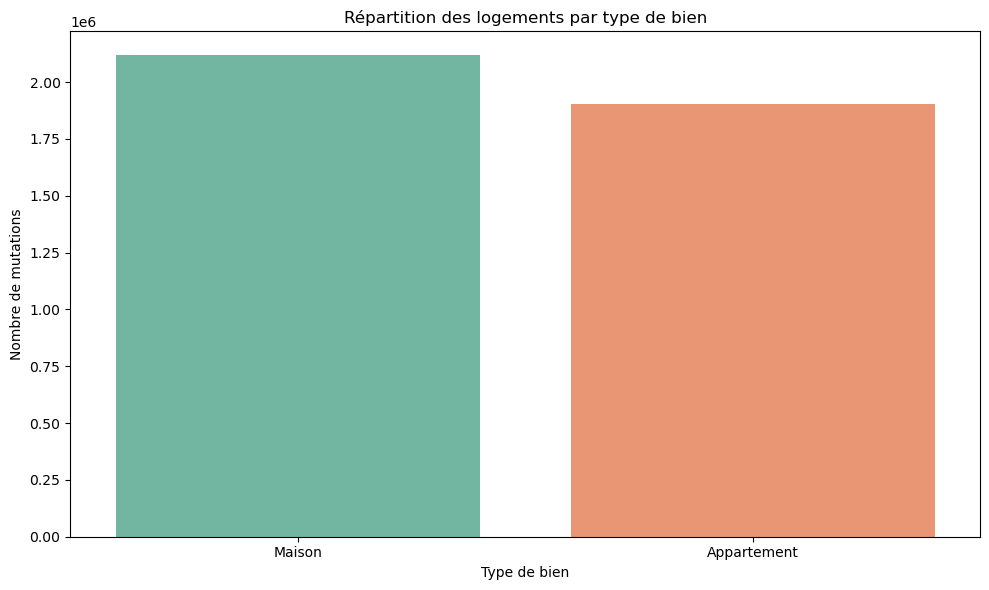

Distribution :
type_bien
Maison         2117308
Appartement    1902273
Name: count, dtype: int64


In [24]:
# Contrôle visuel de la structure de l'échantillon par type de bien.
plot_df = sanitize_for_plot(df_final, x="type_bien")
plt.figure(figsize=(10, 6))
sns.countplot(data=plot_df, x="type_bien", palette="Set2")
plt.title("Répartition des logements par type de bien")
plt.xlabel("Type de bien")
plt.ylabel("Nombre de mutations")
plt.tight_layout()
plt.show()

print(f"Distribution :")
print(df_final["type_bien"].value_counts())

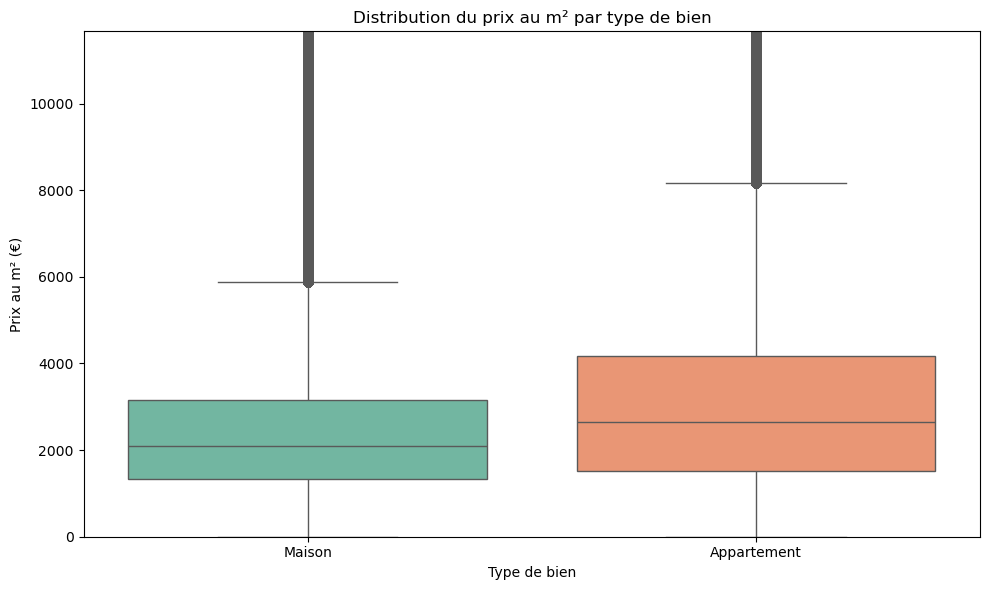


Statistiques prix_m2 :
                 count         mean          std       min          25%  \
type_bien                                                                 
Appartement  1901452.0  3285.004060  3466.708829  0.000008  1521.537741   
Maison       2115652.0  2508.676639  6704.600731  0.000011  1325.393773   

                     50%          75%           max  
type_bien                                            
Appartement  2644.444444  4180.201151  1.577185e+06  
Maison       2103.191489  3145.670887  6.072185e+06  


In [25]:
# Comparaison des distributions de prix au m² selon le type de bien.
# Cette séparation évite de confondre des segments de marché structurellement différents.
plot_df = sanitize_for_plot(df_final, x="type_bien", y="prix_m2")
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x="type_bien", y="prix_m2", palette="Set2")
plt.title("Distribution du prix au m² par type de bien")
plt.xlabel("Type de bien")
plt.ylabel("Prix au m² (€)")
plt.ylim(0, np.nanpercentile(plot_df["prix_m2"], 99))
plt.tight_layout()
plt.show()

print(f"\nStatistiques prix_m2 :")
print(df_final.groupby("type_bien")["prix_m2"].describe())

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse de la distribution du prix au m² par type de bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Les appartements présentent un prix au m² globalement plus élevé que les maisons, avec une médiane supérieure d’environ 500 €/m². La dispersion des prix est également plus importante pour les appartements, traduisant une plus forte hétérogénéité du marché. Les valeurs extrêmes sont nombreuses dans les deux catégories, mais davantage marquées pour les appartements, avec des biens dépassant 8 000 €/m². Les maisons affichent une distribution plus concentrée autour de la médiane, suggérant un marché plus homogène. La présence d’outliers élevés dans les deux segments confirme l’existence de zones géographiques ou de biens atypiques fortement valorisés..</div>
</div>

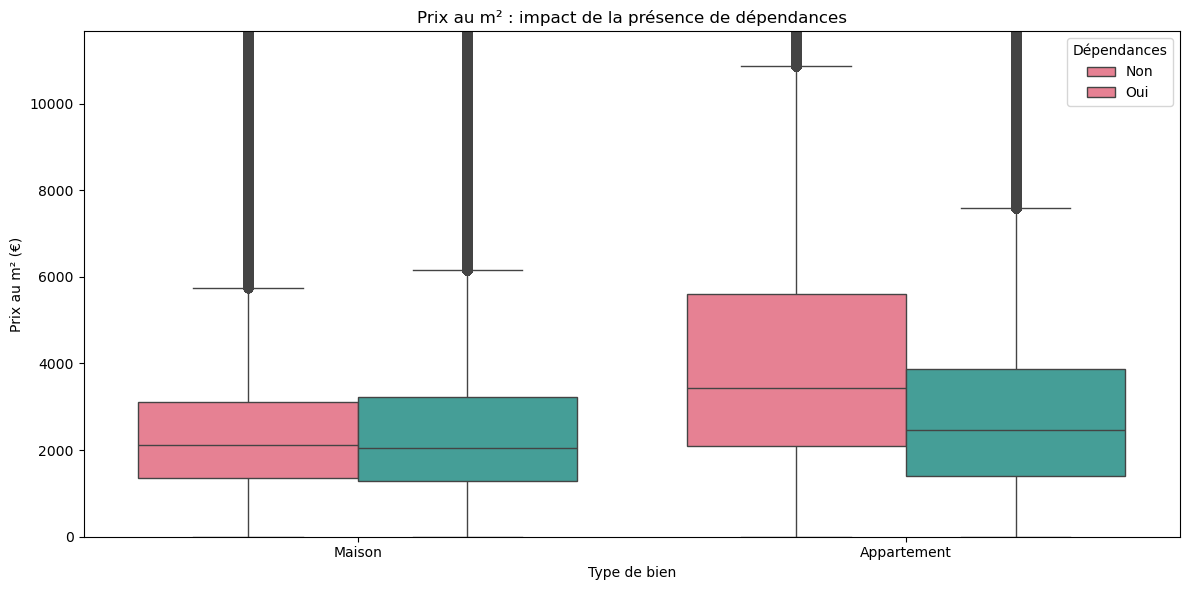


Impact des dépendances :
                                      50%      count
type_bien   avec_dependances                        
Appartement False             3425.086018   414421.0
            True              2457.079855  1487031.0
Maison      False             2124.500000  1408567.0
            True              2057.371429   707085.0


In [26]:
# Analyse de l'effet potentiel des dépendances sur les niveaux de prix unitaires.
plot_df = sanitize_for_plot(df_final, x="type_bien", y="prix_m2", hue="avec_dependances")
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="type_bien", y="prix_m2", hue="avec_dependances", palette="husl")
plt.title("Prix au m² : impact de la présence de dépendances")
plt.xlabel("Type de bien")
plt.ylabel("Prix au m² (€)")
plt.ylim(0, np.nanpercentile(plot_df["prix_m2"], 99))
plt.legend(title="Dépendances", labels=["Non", "Oui"] )
plt.tight_layout()
plt.show()

print(f"\nImpact des dépendances :")
impact = df_final.groupby(["type_bien", "avec_dependances"])["prix_m2"].describe()[["50%", "count"]]
print(impact)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de l’impact des dépendances</h3>
  <div style="color: #4b5563; font-size: 14px;">Le graphique montre que la présence de dépendances n’a pas le même impact selon le type de bien. Pour les maisons, les distributions restent relativement proches : la présence d’une dépendance semble fréquente mais n’entraîne pas de différence majeure de prix au m². Cela s’explique probablement par le fait que garage, cave ou annexe font souvent partie de l’ensemble résidentiel classique des maisons. Pour les appartements, l’écart apparaît plus marqué. Les appartements associés à des dépendances présentent des niveaux de prix et une dispersion plus élevés, ce qui peut refléter des biens plus premium ou situés dans des zones tendues où parking et annexes constituent une forte valeur ajoutée. Le graphique met également en évidence une forte dispersion des prix dans tous les segments, avec de nombreux points extrêmes. Cela confirme que la présence de dépendances constitue un signal explicatif intéressant, mais insuffisant à elle seule pour expliquer les écarts de valorisation immobilière.</div>
</div>

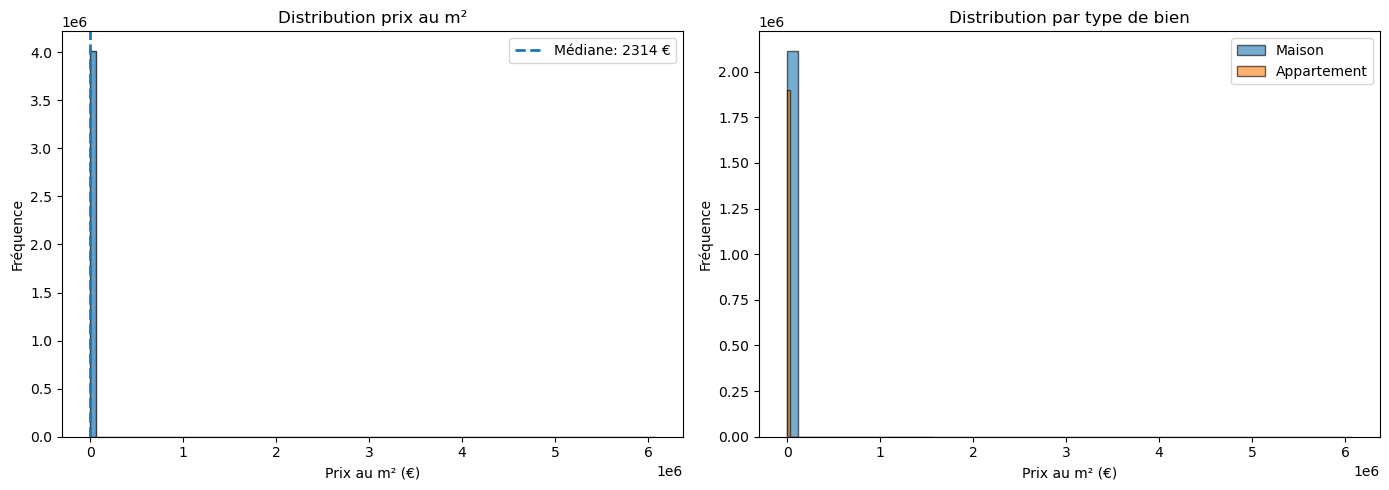

In [27]:
# Analyse de la distribution globale du prix au m².
# La comparaison par type de bien complète la lecture des asymétries éventuelles.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prix = df_final["prix_m2"].dropna()
axes[0].hist(prix, bins=100, edgecolor="black", alpha=0.7)
axes[0].axvline(prix.median(), linestyle="--", linewidth=2, label=f"Médiane: {prix.median():.0f} €")
axes[0].set_title("Distribution prix au m²")
axes[0].set_xlabel("Prix au m² (€)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

for bien in df_final["type_bien"].dropna().unique():
    subset = df_final.loc[df_final["type_bien"].eq(bien), "prix_m2"].dropna()
    axes[1].hist(subset, bins=50, alpha=0.6, label=bien, edgecolor="black")

axes[1].set_title("Distribution par type de bien")
axes[1].set_xlabel("Prix au m² (€)")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Distribution globale du prix au m²</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule étudie la distribution brute du prix au m². Elle met en évidence l’asymétrie du marché, la concentration du cœur de distribution et la présence de valeurs extrêmes.</div>
</div>

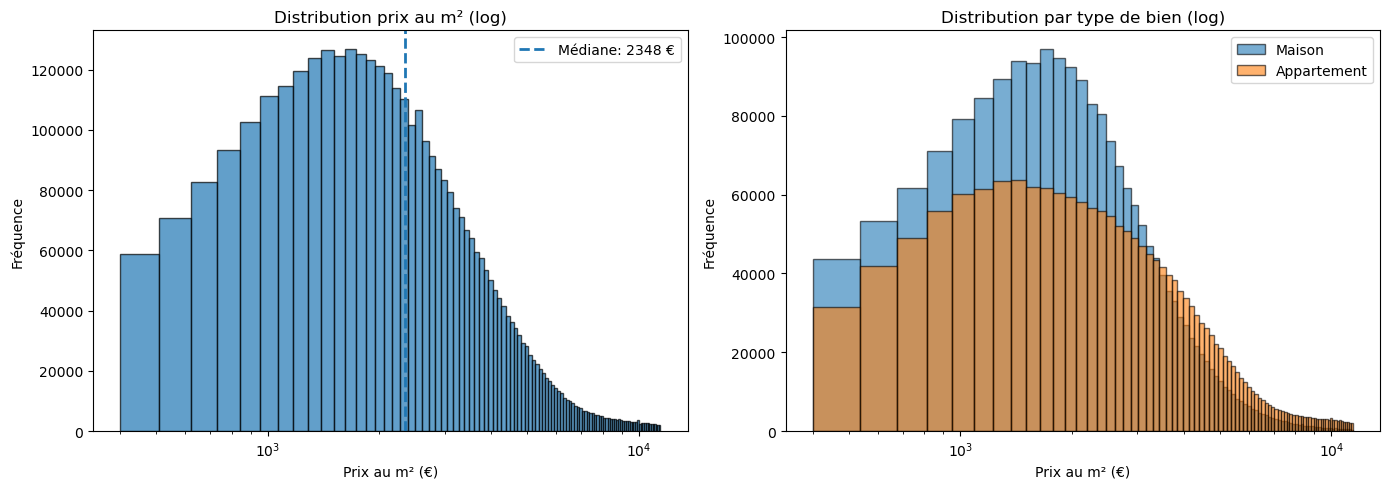

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Filtrage analytique ---
df_plot = df_final.copy()

df_plot = df_plot[
    (df_plot["prix_m2"].notna())
    & (df_plot["surface_reference"] >= 9)
    & (df_plot["surface_reference"] <= 500)
    & (df_plot["prix_m2"] > 300)
    & (df_plot["prix_m2"] < 20000)
]

# Option : filtrage statistique complémentaire
q01 = df_plot["prix_m2"].quantile(0.01)
q99 = df_plot["prix_m2"].quantile(0.99)

df_plot = df_plot[
    (df_plot["prix_m2"] >= q01)
    & (df_plot["prix_m2"] <= q99)
]

# --- Graphique global ---
prix = df_plot["prix_m2"]

axes[0].hist(prix, bins=100, edgecolor="black", alpha=0.7)
axes[0].axvline(prix.median(), linestyle="--", linewidth=2,
                label=f"Médiane: {prix.median():.0f} €")

axes[0].set_xscale("log")   # 🔑 clé de lisibilité
axes[0].set_title("Distribution prix au m² (log)")
axes[0].set_xlabel("Prix au m² (€)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# --- Par type de bien ---
for bien in ["Maison", "Appartement"]:
    subset = df_plot.loc[df_plot["type_bien"] == bien, "prix_m2"]

    axes[1].hist(subset, bins=80, alpha=0.6, label=bien, edgecolor="black")

axes[1].set_xscale("log")   # 🔑 clé aussi ici
axes[1].set_title("Distribution par type de bien (log)")
axes[1].set_xlabel("Prix au m² (€)")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse de la distribution des prix au m² selon typologie</h3>
  <div style="color: #4b5563; font-size: 14px;">La distribution des prix au m² présente une asymétrie positive marquée, avec une concentration importante des biens autour des valeurs médianes et une longue traîne vers les prix élevés. La transformation logarithmique permet de mieux visualiser la structure de la distribution en réduisant l’effet des valeurs extrêmes. La médiane du prix au m² se situe autour de 2 348 €, ce qui confirme un marché majoritairement concentré sur des niveaux de prix intermédiaires. Les distributions des maisons et des appartements restent proches sur la partie centrale, mais les appartements présentent une densité plus importante sur les niveaux de prix élevés. Les biens les plus chers concernent principalement le segment des appartements, avec une présence plus marquée dans les zones à forte tension immobilière. La superposition des distributions met en évidence une variabilité plus forte pour les appartements, traduisant un marché davantage segmenté selon la localisation et le standing des biens..</div>
</div>

In [29]:
df_plot.groupby("source_surface_reference")["prix_m2"].median()

source_surface_reference
bati             2151.388889
bati_fallback    2985.074627
carrez           2464.186563
Name: prix_m2, dtype: float64

In [ ]:
# Construction d’un sous-ensemble "core" de la base finale.
#
# L’objectif est de conserver uniquement les observations
# dont la surface de référence provient :
# - soit de la surface Carrez,
# - soit de la surface bâtie.
#
# Ces deux sources sont considérées comme les plus fiables
# et les plus cohérentes pour les analyses résidentielles.

df_core = df_final[

    # Sélection des lignes dont la variable
    # "source_surface_reference"
    # appartient à la liste ["carrez", "bati"].
    #
    # isin([...]) retourne :
    # - True si la valeur appartient à la liste,
    # - False sinon.
    #
    # Exemple :
    # "carrez" -> True
    # "bati"   -> True
    # "terrain" -> False
    df_final["source_surface_reference"].isin(["carrez", "bati"])

]

# Résultat :
# df_core contient uniquement les mutations
# jugées suffisamment cohérentes pour travailler
# sur les indicateurs de prix au m² résidentiels.
#
# Cette étape permet notamment :
# - de réduire le bruit statistique,
# - d’écarter certaines surfaces peu interprétables,
# - d’améliorer la comparabilité des biens.

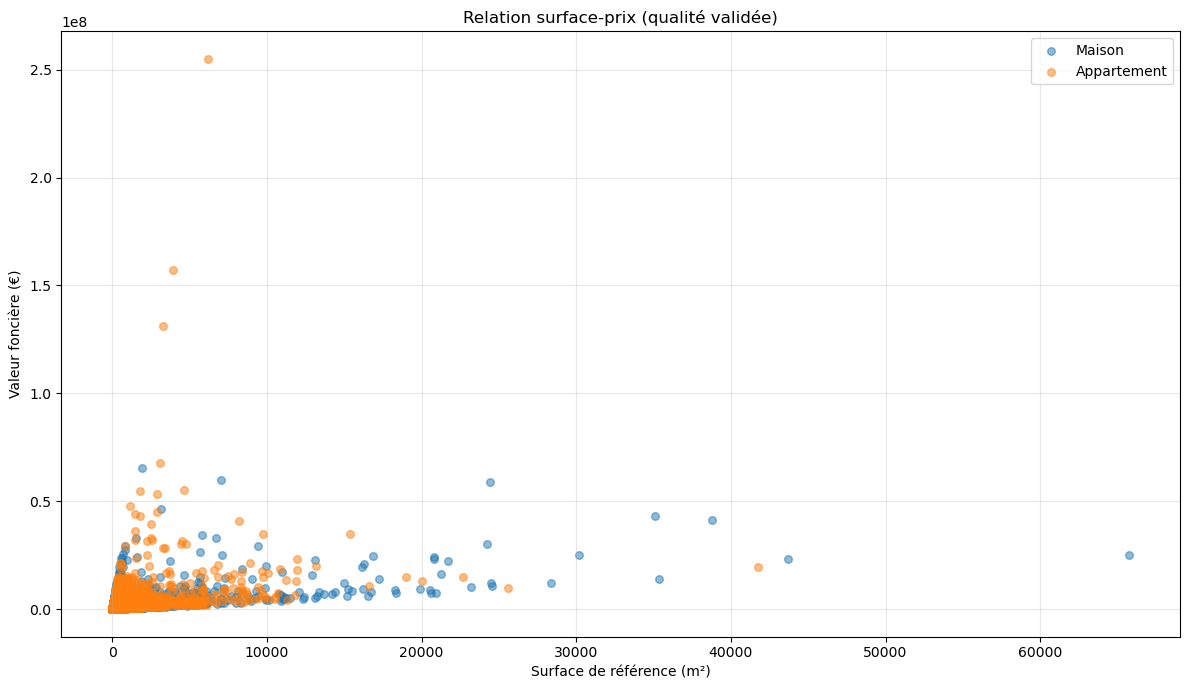

In [31]:
# Contrôle de cohérence entre surface de référence et valeur foncière.
# Une relation croissante est attendue, avec dispersion liée aux effets territoriaux et qualitatifs.
plot_df = df_final[df_final["flag_qualite_globale"]].copy()
plt.figure(figsize=(12, 7))
for bien in plot_df["type_bien"].unique():
    subset = plot_df[plot_df["type_bien"] == bien]
    plt.scatter(subset["surface_reference"], subset["valeur_fonciere"], 
               alpha=0.5, label=bien, s=30)

plt.xlabel("Surface de référence (m²)")
plt.ylabel("Valeur foncière (€)")
plt.title("Relation surface-prix (qualité validée)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Base analytique principale</h3>
  <div style="color: #4b5563; font-size: 14px;">Analyse de la relation entre la surface et la valeur foncière Une corrélation positive apparaît entre la surface de référence et la valeur foncière : les biens de grande taille tendent globalement à présenter des montants de transaction plus élevés. La majorité des transactions se concentre toutefois sur des surfaces relativement faibles et des valeurs foncières modérées, traduisant la structure dominante du marché résidentiel. La dispersion des prix augmente avec la surface, indiquant une forte hétérogénéité des biens les plus grands. Les appartements sont principalement concentrés sur les petites et moyennes surfaces, tandis que les maisons occupent davantage les surfaces élevées. Plusieurs valeurs extrêmes sont observées, notamment sur le segment des appartements, avec des transactions atypiques atteignant des niveaux très élevés de valeur foncière. La présence de biens très grands associés à des montants relativement modérés suggère l’existence de marchés locaux moins tendus ou de biens à usage spécifique. Le graphique met également en évidence une concentration dense de points proches de l’origine, caractéristique d’une distribution fortement asymétrique du marché immobilier.</div>
</div>

In [32]:
# Construction d'une base analytique dédiée aux visualisations et comparaisons.
# df_final reste la base économique complète ; df_analytique est une vue filtrée pour les analyses prix/surface.

df_analytique = df_final.loc[
    df_final["flag_qualite_globale"]
    & df_final["surface_reference"].between(9, 500)
    & df_final["prix_m2"].between(300, 20_000)
].copy()

print("=== Volume vs qualité analytique ===")
print(f"Base économique complète : {len(df_final):,} mutations")
print(f"Base analytique prix/m²  : {len(df_analytique):,} mutations")
print(f"Part conservée           : {len(df_analytique) / len(df_final):.1%}")

print("\n=== Composition type de bien - base complète ===")
display(
    df_final["type_bien"]
    .value_counts(dropna=False)
    .to_frame("nb_mutations")
    .assign(part=lambda x: x["nb_mutations"] / len(df_final))
)

print("\n=== Composition type de bien - base analytique ===")
display(
    df_analytique["type_bien"]
    .value_counts(dropna=False)
    .to_frame("nb_mutations")
    .assign(part=lambda x: x["nb_mutations"] / len(df_analytique))
)


=== Volume vs qualité analytique ===
Base économique complète : 4,019,581 mutations
Base analytique prix/m²  : 3,915,199 mutations
Part conservée           : 97.4%

=== Composition type de bien - base complète ===


,nb_mutations,part
type_bien,,
Maison,2117308,0.526748
Appartement,1902273,0.473252



=== Composition type de bien - base analytique ===


,nb_mutations,part
type_bien,,
Maison,2052406,0.524215
Appartement,1862793,0.475785


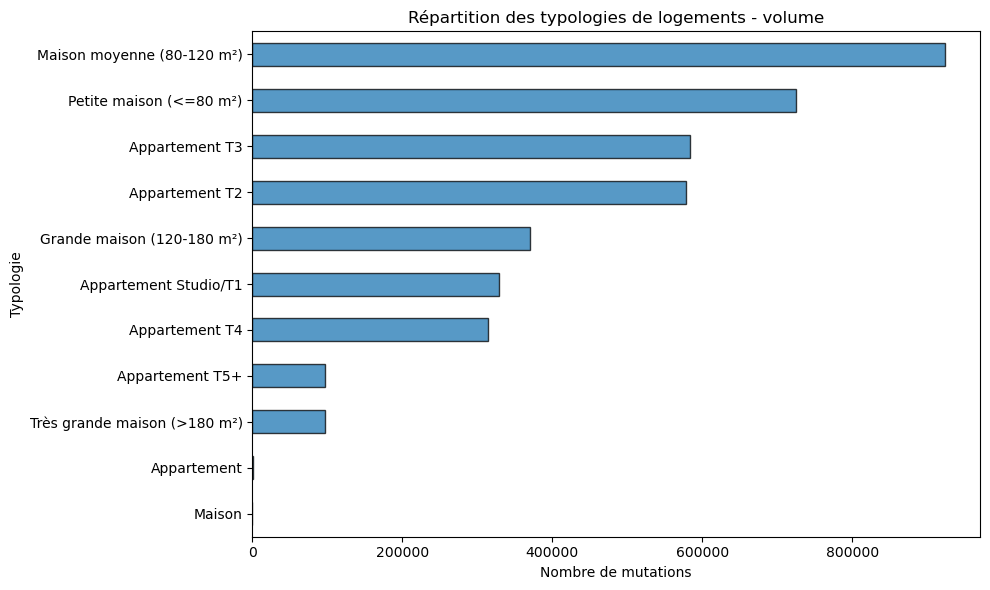

In [33]:
# Répartition des typologies en volume.
typo_counts = (
    df_final["sous_categorie_logement"]
    .value_counts(dropna=False)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
typo_counts.plot(kind="barh", ax=ax, edgecolor="black", alpha=0.75)

ax.set_title("Répartition des typologies de logements - volume")
ax.set_xlabel("Nombre de mutations")
ax.set_ylabel("Typologie")

plt.tight_layout()
plt.show()


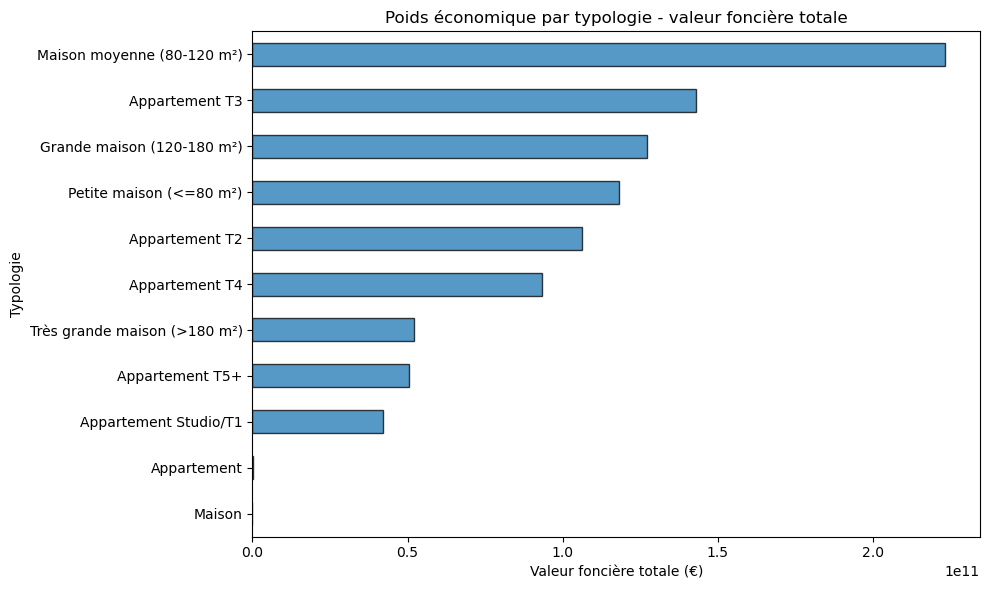

In [34]:
# Répartition des typologies en valeur foncière.
# Cette lecture complète le volume : un segment peu fréquent peut peser fortement économiquement.
typo_value = (
    df_final
    .groupby("sous_categorie_logement", dropna=False)["valeur_fonciere"]
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
typo_value.plot(kind="barh", ax=ax, edgecolor="black", alpha=0.75)

ax.set_title("Poids économique par typologie - valeur foncière totale")
ax.set_xlabel("Valeur foncière totale (€)")
ax.set_ylabel("Typologie")

plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Distribution après filtrage analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule vérifie la distribution du prix au m² sur la base analytique. Elle permet de confirmer que le filtrage améliore la lisibilité tout en conservant une diversité de marchés.</div>
</div>

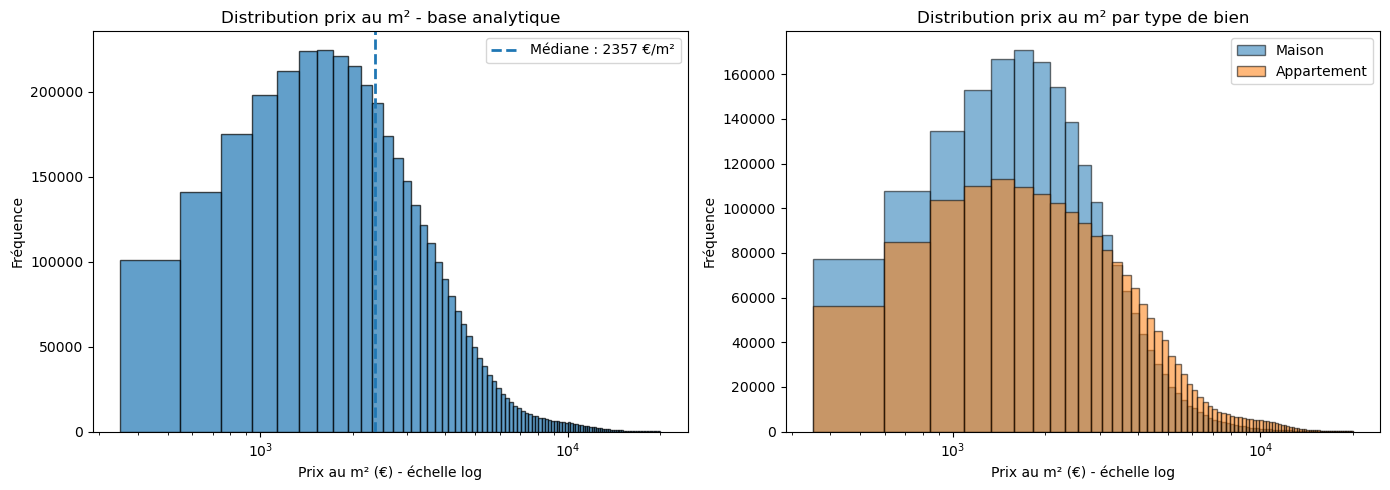

In [35]:
# Distribution propre du prix au m², sur la base analytique.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prix = df_analytique["prix_m2"].dropna()

axes[0].hist(prix, bins=100, edgecolor="black", alpha=0.7)
axes[0].axvline(
    prix.median(),
    linestyle="--",
    linewidth=2,
    label=f"Médiane : {prix.median():.0f} €/m²"
)
axes[0].set_xscale("log")
axes[0].set_title("Distribution prix au m² - base analytique")
axes[0].set_xlabel("Prix au m² (€) - échelle log")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

for bien in ["Maison", "Appartement"]:
    subset = df_analytique.loc[df_analytique["type_bien"].eq(bien), "prix_m2"].dropna()
    axes[1].hist(subset, bins=80, alpha=0.55, label=bien, edgecolor="black")

axes[1].set_xscale("log")
axes[1].set_title("Distribution prix au m² par type de bien")
axes[1].set_xlabel("Prix au m² (€) - échelle log")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de la distribution des prix au m²</h3>
  <div style="color: #4b5563; font-size: 14px;">Le graphique de gauche montre que la distribution des prix au m² reste fortement asymétrique, avec une longue queue vers les prix élevés. L’utilisation d’une échelle logarithmique améliore toutefois la lisibilité et permet de mieux visualiser le cœur de la distribution. La médiane se situe autour de 2 357 €/m², ce qui correspond au centre du marché résidentiel observé dans la base analytique. Le graphique de droite met en évidence des différences de structure entre maisons et appartements. Les appartements apparaissent globalement plus valorisés, avec une distribution légèrement décalée vers les prix élevés. Les maisons présentent au contraire une dispersion plus large sur les niveaux intermédiaires et bas du marché. Malgré ces différences, les distributions restent largement recouvrantes : le type de bien constitue donc un signal explicatif important, mais insuffisant à lui seul pour expliquer les écarts de prix observés. Cette lecture justifie la poursuite d’analyses intégrant également des variables territoriales, temporelles et structurelles.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Synthèse par type de bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule compare les prix, volumes et dispersions entre appartements et maisons. Elle aide à déterminer si ces marchés doivent être analysés ensemble ou séparément dans les notebooks suivants.</div>
</div>

In [36]:
# Synthèse descriptive des prix par type de bien.
print("=== Prix au m² par type de bien - base analytique ===")
display(
    df_analytique
    .groupby("type_bien")["prix_m2"]
    .agg(
        nb_mutations="count",
        prix_m2_q05=lambda s: s.quantile(0.05),
        prix_m2_median="median",
        prix_m2_q95=lambda s: s.quantile(0.95),
        prix_m2_mean="mean"
    )
    .round(0)
)


=== Prix au m² par type de bien - base analytique ===


,nb_mutations,prix_m2_q05,prix_m2_median,prix_m2_q95,prix_m2_mean
type_bien,,,,,
Appartement,1862793,711.0,2682.0,8452.0,3292.0
Maison,2052406,661.0,2149.0,5625.0,2534.0


=== Prix et surfaces selon la source de surface de référence ===


,nb_mutations,surface_median,prix_m2_median
source_surface_reference,,,
bati,2117202,92.0,2103.2
carrez,1282011,74.5,2454.6
bati_fallback,620172,56.0,2980.8
NaN,196,NaN,NaN


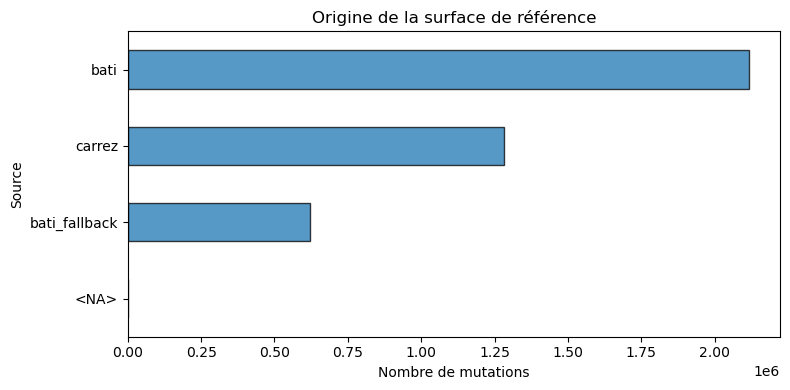

In [37]:
# Effet de l'origine de la surface sur les niveaux de prix et de surface.
print("=== Prix et surfaces selon la source de surface de référence ===")
display(
    df_final
    .groupby("source_surface_reference", dropna=False)
    .agg(
        nb_mutations=("id_mutation", "count"),
        surface_median=("surface_reference", "median"),
        prix_m2_median=("prix_m2", "median")
    )
    .sort_values("nb_mutations", ascending=False)
    .round(1)
)

surface_source = (
    df_final["source_surface_reference"]
    .value_counts(dropna=False)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
surface_source.plot(kind="barh", ax=ax, edgecolor="black", alpha=0.75)

ax.set_title("Origine de la surface de référence")
ax.set_xlabel("Nombre de mutations")
ax.set_ylabel("Source")

plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de l’origine des surfaces de référence</h3>
  <div style="color: #4b5563; font-size: 14px;">Le graphique montre que la majorité des surfaces de référence utilisées dans la base analytique proviennent des surfaces bâties déclarées dans DVF. Les surfaces Carrez représentent également une part importante des observations, principalement pour les appartements, où cette mesure est souvent plus pertinente pour l’analyse résidentielle. Les cas de type  bâti_fallback  correspondent à des situations où aucune surface Carrez exploitable n’était disponible et où une logique de repli a été utilisée afin de conserver une surface cohérente pour le calcul des indicateurs économiques. Cette répartition confirme que la base finale repose majoritairement sur des surfaces directement exploitables pour les analyses de prix au m². Elle met également en évidence l’hétérogénéité structurelle des données DVF, qui nécessite des règles de consolidation pour construire une surface de référence homogène à l’échelle nationale.</div>
</div>

In [ ]:
# SEGMENTATION DES PRIX AU M²

# L’objectif de cette étape est de transformer
# une variable continue (prix_m2)
# en catégories plus faciles à lire et interpréter.
#
# Deux logiques complémentaires sont utilisées :
#
# 1) Une segmentation métier nationale :
#    → lecture simple et intuitive du marché.
#
# 2) Une segmentation relative par type de bien :
#    → comparaison des biens à l’intérieur
#      de leur propre segment de marché.


def add_price_segments(df):
    """Ajoute des segments de prix au m² pour l'analyse économique."""

    # Copie de sécurité du DataFrame.
    df = df.copy()

    # SEGMENTATION METIER

    # Définition de bornes de prix au m².
    #
    # Exemple :
    # - moins de 1000 €/m² → entrée de marché
    # - entre 2000 et 4000 €/m² → intermédiaire
    bins_metier = [0, 1000, 2000, 4000, 7000, np.inf]

    # Libellés associés aux intervalles.
    labels_metier = [
        "Entrée de marché",
        "Abordable",
        "Intermédiaire",
        "Élevé",
        "Premium"
    ]

    # pd.cut :
    # découpe une variable numérique en classes.
    #
    # Chaque mutation reçoit ici
    # une catégorie de prix lisible.
    df["segment_prix_m2"] = pd.cut(
        df["prix_m2"],
        bins=bins_metier,
        labels=labels_metier,
        include_lowest=True
    )

        # SEGMENTATION RELATIVE
  
    # Ici, l’objectif change :
    #
    # on ne compare plus tous les biens ensemble,
    # mais chaque bien par rapport à son propre marché.
    #
    # Exemple :
    # un appartement "Q5 très élevé"
    # est parmi les appartements les plus chers,
    # même s’il reste moins cher qu’une maison premium.

    labels_quantiles = [
        "Q1 très bas",
        "Q2 bas",
        "Q3 médian",
        "Q4 élevé",
        "Q5 très élevé"
    ]

    # Fonction sécurisée de découpage en quintiles.
    def safe_qcut(s):

        # Conversion en float pour sécuriser les calculs.
        s = s.astype(float)

        # Si trop peu de valeurs ou pas assez de diversité,
        # le découpage statistique n’est pas fiable.
        #
        # Dans ce cas :
        # → retourne des valeurs manquantes.
        if s.notna().sum() < 5 or s.nunique(dropna=True) < 5:
            return pd.Series(pd.NA, index=s.index, dtype="object")

        # pd.qcut :
        # découpe la distribution en quantiles équilibrés.
        #
        # q=5 :
        # création de quintiles (~20 % chacun).
        return pd.qcut(
            s,
            q=5,
            labels=labels_quantiles,
            duplicates="drop"
        )

    # groupby("type_bien") :
    # le découpage est réalisé séparément
    # pour maisons et appartements.
    df["segment_prix_type"] = (

        df.groupby("type_bien", group_keys=False)["prix_m2"]

        # Application du découpage statistique
        # à chaque segment immobilier.
        .apply(safe_qcut)
    )

    return df


# APPLICATION DE LA SEGMENTATION
# Ajout des segments de prix
# dans la base analytique.
df_analytique = add_price_segments(df_analytique)

# Confirmation de l’opération.
print("✓ Segments de prix ajoutés à df_analytique")

# Affichage du volume total.
print(f"Base analytique segmentée : {len(df_analytique):,} mutations")


# REPARTITION DES SEGMENTS METIER

print("=== Répartition par segment métier ===")

display(

    # Comptage des mutations par segment.
    df_analytique["segment_prix_m2"]

    .value_counts(dropna=False)

    # Renomme l’index pour améliorer la lisibilité.
    .rename_axis("segment_prix_m2")

    # Transforme la série en DataFrame.
    .reset_index(name="nb_mutations")

    # Calcule la part relative de chaque segment.
    .assign(
        part=lambda x:
        (x["nb_mutations"] / len(df_analytique)).round(3)
    )
)

# REPARTITION RELATIVE PAR TYPE DE BIEN
print("=== Répartition par segment relatif au type de bien ===")

display(

    # Tableau croisé :
    # lignes = type de bien
    # colonnes = quintiles de prix.
    pd.crosstab(
        df_analytique["type_bien"],
        df_analytique["segment_prix_type"],

        # normalize="index" :
        # transforme les volumes en proportions.
        normalize="index"
    )

    # Arrondi pour améliorer la lecture.
    .round(3)
)
# UTILITE DE CETTE ETAPE

# Cette segmentation permet :
#
# - de simplifier la lecture du marché,
# - d’identifier rapidement les niveaux de gamme,
# - de comparer les biens au sein de leur catégorie,
# - de préparer les futures analyses territoriales,
# - et de construire des profils de marché plus interprétables.


✓ Segments de prix ajoutés à df_analytique
Base analytique segmentée : 3,915,199 mutations
=== Répartition par segment métier ===


,segment_prix_m2,nb_mutations,part
0,Intermédiaire,1523804,0.389
1,Abordable,1107654,0.283
2,Élevé,611349,0.156
3,Entrée de marché,481255,0.123
4,Premium,191137,0.049


=== Répartition par segment relatif au type de bien ===


segment_prix_type,Q1 très bas,Q2 bas,Q3 médian,Q4 élevé,Q5 très élevé
type_bien,,,,,
Appartement,0.2,0.2,0.200,0.200,0.2
Maison,0.2,0.2,0.204,0.196,0.2


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de la segmentation relative</h3>
  <div style="color: #4b5563; font-size: 14px;">La répartition apparaît presque parfaitement équilibrée entre les cinq segments de prix pour les appartements comme pour les maisons. Ce résultat est normal : la segmentation a été construite avec un découpage en quintiles ( qcut ), ce qui force statistiquement des groupes de taille proche. L’intérêt de cette approche n’est donc pas de mesurer les volumes de marché, mais de positionner chaque bien relativement aux autres biens de même type. Un appartement classé en “Q5 très élevé” appartient ainsi aux 20 % les plus chers des appartements, indépendamment du niveau absolu des maisons. Cette segmentation relative permet de comparer plus finement les comportements de marché, les localisations ou les profils de biens à l’intérieur de chaque catégorie résidentielle, sans être biaisé par les différences structurelles de prix entre appartements et maisons.</div>
</div>

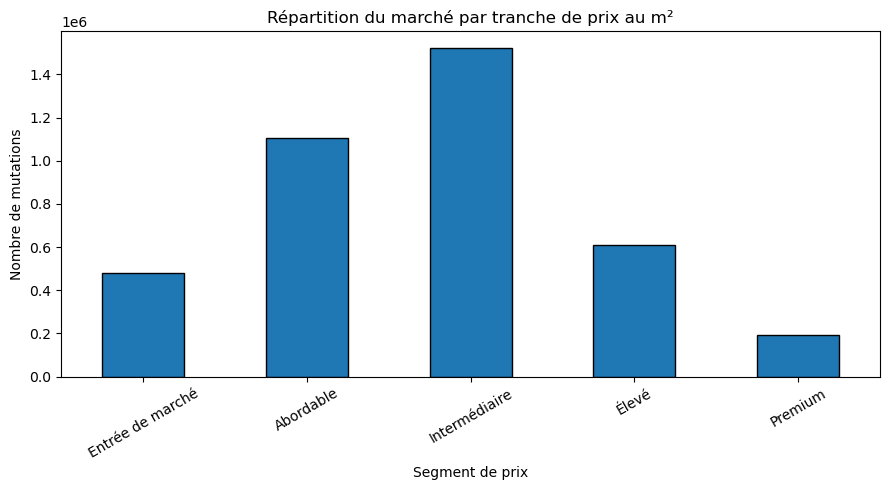

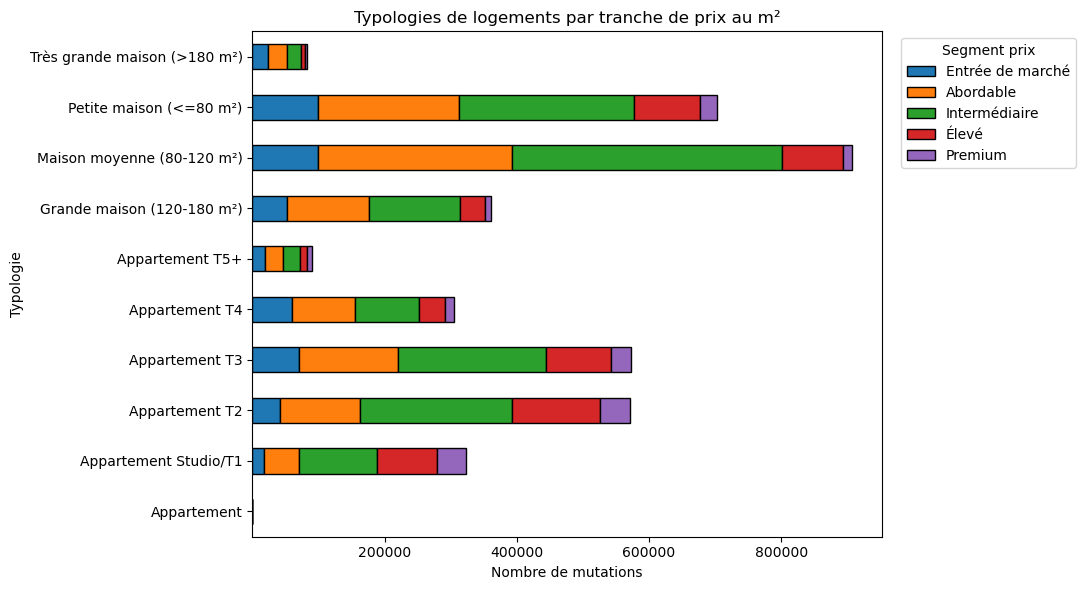

In [39]:
# Répartition des segments de prix en volume.
segment_order = ["Entrée de marché", "Abordable", "Intermédiaire", "Élevé", "Premium"]

seg_counts = (
    df_analytique["segment_prix_m2"]
    .value_counts()
    .reindex(segment_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
seg_counts.plot(kind="bar", ax=ax, edgecolor="black")

ax.set_title("Répartition du marché par tranche de prix au m²")
ax.set_xlabel("Segment de prix")
ax.set_ylabel("Nombre de mutations")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Croisement typologie × segment de prix.
crosstab_typo_prix = pd.crosstab(
    df_analytique["sous_categorie_logement"],
    df_analytique["segment_prix_m2"]
).reindex(columns=segment_order)

# Affichage des typologies les plus représentées pour préserver la lisibilité.
top_typologies = (
    df_analytique["sous_categorie_logement"]
    .value_counts()
    .head(10)
    .index
)

fig, ax = plt.subplots(figsize=(11, 6))
crosstab_typo_prix.loc[top_typologies].sort_index().plot(
    kind="barh",
    stacked=True,
    ax=ax,
    edgecolor="black"
)

ax.set_title("Typologies de logements par tranche de prix au m²")
ax.set_xlabel("Nombre de mutations")
ax.set_ylabel("Typologie")
ax.legend(title="Segment prix", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des typologies de logements par segment de prix</h3>
  <div style="color: #4b5563; font-size: 14px;">Le graphique montre que les différentes typologies de logements ne se répartissent pas de manière homogène selon les niveaux de prix au m². Les appartements de petite taille, notamment les studios et T1, sont proportionnellement plus présents dans les segments élevés et premium, ce qui reflète la forte valorisation des petites surfaces dans les zones tendues. À l’inverse, les maisons moyennes et petites se concentrent davantage dans les segments intermédiaires ou abordables, traduisant une structure de marché plus diffuse géographiquement et moins dépendante des centres urbains les plus chers. Les très grandes maisons restent peu nombreuses dans la base, mais apparaissent réparties sur plusieurs niveaux de prix, ce qui suggère une forte hétérogénéité de ce segment : certaines correspondent à des marchés ruraux peu valorisés, d’autres à des biens haut de gamme. Cette lecture confirme que la typologie du bien constitue un facteur structurant du positionnement prix. Elle montre également que les effets de surface, de localisation et de type de bien interagissent fortement dans la formation des prix immobiliers.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Profil économique des segments</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule synthétise chaque segment : volume, prix médian, valeur médiane, surface médiane et composition par type de bien. Elle transforme les segments statistiques en profils de marché interprétables.</div>
</div>

=== Profil économique des segments de prix ===


,nb_mutations,part_mutations,prix_m2_median,valeur_median,surface_median,part_appartements,part_maisons
segment_prix_m2,,,,,,,
Entrée de marché,481255,12.3%,741,"75,000",107,43.2%,56.8%
Abordable,1107654,28.3%,"1,515","138,650",91,40.4%,59.6%
Intermédiaire,1523804,38.9%,"2,789","218,800",80,45.5%,54.5%
Élevé,611349,15.6%,"4,875","320,000",65,60.9%,39.1%
Premium,191137,4.9%,"9,161","465,000",50,73.8%,26.2%


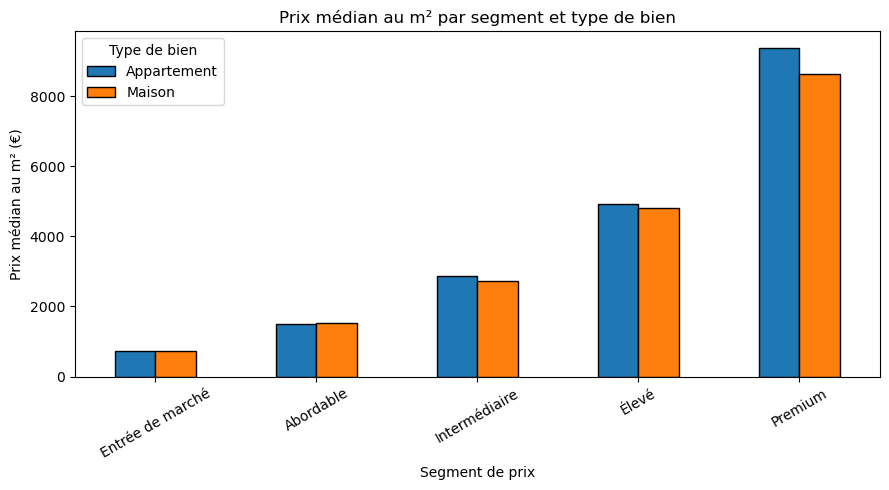

In [ ]:
# Synthèse économique des segments de prix.
#
# Cette cellule construit une vue d’ensemble des différents segments
# de marché définis précédemment à partir du prix au m².
#
# L’objectif est de comparer :
# - le volume de mutations,
# - le niveau de prix,
# - la valeur des biens,
# - les surfaces,
# - ainsi que la structure appartements / maisons.


# Agrégation des indicateurs économiques par segment de prix.
segment_summary = (
    df_analytique

    # Regroupe les mutations selon le segment métier de prix au m².
    .groupby("segment_prix_m2", observed=False)

    # Calcul des indicateurs principaux pour chaque segment.
    .agg(

        # Nombre total de mutations.
        nb_mutations=("id_mutation", "count"),

        # Prix médian au m² du segment.
        prix_m2_median=("prix_m2", "median"),

        # Valeur foncière médiane des mutations.
        valeur_median=("valeur_fonciere", "median"),

        # Surface médiane des biens.
        surface_median=("surface_reference", "median"),

        # Part d'appartements dans le segment.
        part_appartements=(
            "type_bien",
            lambda s: s.eq("Appartement").mean()
        ),

        # Part de maisons dans le segment.
        part_maisons=(
            "type_bien",
            lambda s: s.eq("Maison").mean()
        )
    )

    # Réorganisation des segments selon l'ordre métier souhaité.
    .reindex(segment_order)
)

# Calcul du poids relatif de chaque segment dans la base analytique.
segment_summary["part_mutations"] = (
    segment_summary["nb_mutations"]
    / segment_summary["nb_mutations"].sum()
)

print("=== Profil économique des segments de prix ===")

# Affichage formaté du tableau de synthèse.
display(
    segment_summary[[
        "nb_mutations",
        "part_mutations",
        "prix_m2_median",
        "valeur_median",
        "surface_median",
        "part_appartements",
        "part_maisons"
    ]]
    .style.format({
        "part_mutations": "{:.1%}",
        "prix_m2_median": "{:,.0f}",
        "valeur_median": "{:,.0f}",
        "surface_median": "{:,.0f}",
        "part_appartements": "{:.1%}",
        "part_maisons": "{:.1%}"
    })
)


# Comparaison du prix médian par segment et type de bien.
#
# Cette analyse permet de vérifier si les niveaux de prix
# sont comparables entre appartements et maisons
# à l’intérieur de chaque segment métier.

prix_segment_type = (
    df_analytique

    # Regroupement par segment de prix et type de bien.
    .groupby(
        ["segment_prix_m2", "type_bien"],
        observed=False
    )["prix_m2"]

    # Calcul du prix médian au m².
    .median()

    # Transformation des types de biens en colonnes.
    .unstack("type_bien")

    # Réorganisation des segments dans l'ordre métier.
    .reindex(segment_order)
)

# Création du graphique.
fig, ax = plt.subplots(figsize=(9, 5))

# Graphique en barres comparant appartements et maisons.
prix_segment_type.plot(
    kind="bar",
    ax=ax,
    edgecolor="black"
)

# Habillage du graphique.
ax.set_title("Prix médian au m² par segment et type de bien")
ax.set_xlabel("Segment de prix")
ax.set_ylabel("Prix médian au m² (€)")

# Rotation des labels pour améliorer la lisibilité.
ax.tick_params(axis="x", rotation=30)

# Ajout de la légende.
ax.legend(title="Type de bien")

# Ajustement automatique des marges.
plt.tight_layout()

# Affichage final.
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des prix médians par segment et type de bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Le graphique montre que les prix médians augmentent logiquement d’un segment à l’autre, ce qui confirme la cohérence de la segmentation métier construite à partir du prix au m². Les appartements apparaissent légèrement plus valorisés que les maisons dans les segments intermédiaires, élevés et premium. Cet écart reflète probablement le poids des grandes métropoles et des zones urbaines tendues, où les appartements concentrent une part importante des prix élevés. À l’inverse, les écarts restent limités dans les segments les plus abordables, ce qui suggère une convergence plus forte des niveaux de prix sur les marchés moins tendus. Cette lecture confirme que le type de bien influence le niveau de valorisation immobilière, mais aussi que les segments de prix capturent une hiérarchie économique cohérente du marché résidentiel.</div>
</div>

In [41]:
# Agrégation départementale sur la base analytique.
agg_dep = (
    df_analytique
    .groupby("code_departement")
    .agg(
        nb_mutations=("id_mutation", "count"),
        prix_m2_median=("prix_m2", "median"),
        prix_m2_q25=("prix_m2", lambda s: s.quantile(0.25)),
        prix_m2_q75=("prix_m2", lambda s: s.quantile(0.75)),
        valeur_totale=("valeur_fonciere", "sum")
    )
    .reset_index()
)

agg_dep["iqr_prix_m2"] = agg_dep["prix_m2_q75"] - agg_dep["prix_m2_q25"]
agg_dep = agg_dep.loc[agg_dep["nb_mutations"] >= 50].copy()

print("=== Départements les plus chers - prix médian €/m² ===")
display(
    agg_dep
    .sort_values("prix_m2_median", ascending=False)
    .head(15)
    .round(0)
)

print("\n=== Départements les moins chers - prix médian €/m² ===")
display(
    agg_dep
    .sort_values("prix_m2_median", ascending=True)
    .head(15)
    .round(0)
)


=== Départements les plus chers - prix médian €/m² ===


,code_departement,nb_mutations,prix_m2_median,prix_m2_q25,prix_m2_q75,valeur_totale,iqr_prix_m2
70,75,145443,7963.0,5098.0,10693.0,8.210945e+10,5595.0
87,92,92311,4814.0,3263.0,7104.0,4.362072e+10,3841.0
5,6,119320,3899.0,2340.0,5402.0,3.671906e+10,3063.0
89,94,70968,3827.0,2548.0,5433.0,2.471421e+10,2885.0
69,74,68847,3731.0,2450.0,5000.0,2.332470e+10,2550.0
88,93,66346,3714.0,2669.0,5005.0,1.795450e+10,2336.0
31,33,106565,3508.0,2415.0,4555.0,3.168906e+10,2140.0
73,78,76422,3451.0,2354.0,4719.0,2.677431e+10,2365.0
78,83,100277,3370.0,2101.0,4850.0,2.703828e+10,2749.0
90,95,63056,3307.0,2313.0,4126.0,1.698652e+10,1813.0



=== Départements les moins chers - prix médian €/m² ===


,code_departement,nb_mutations,prix_m2_median,prix_m2_q25,prix_m2_q75,valeur_totale,iqr_prix_m2
21,23,7430,846.0,585.0,1202.0,6.509605e+08,617.0
55,58,13552,986.0,654.0,1404.0,1.333133e+09,750.0
34,36,12953,1010.0,698.0,1410.0,1.306448e+09,713.0
50,52,8208,1022.0,667.0,1439.0,8.892944e+08,773.0
53,55,8790,1062.0,702.0,1474.0,1.012108e+09,772.0
65,70,10516,1127.0,753.0,1559.0,1.283084e+09,806.0
2,3,18880,1138.0,752.0,1597.0,2.069440e+09,845.0
17,18,17641,1152.0,778.0,1628.0,1.952462e+09,850.0
14,15,8150,1169.0,752.0,1692.0,9.146372e+08,940.0
7,8,13124,1172.0,783.0,1635.0,1.590031e+09,853.0


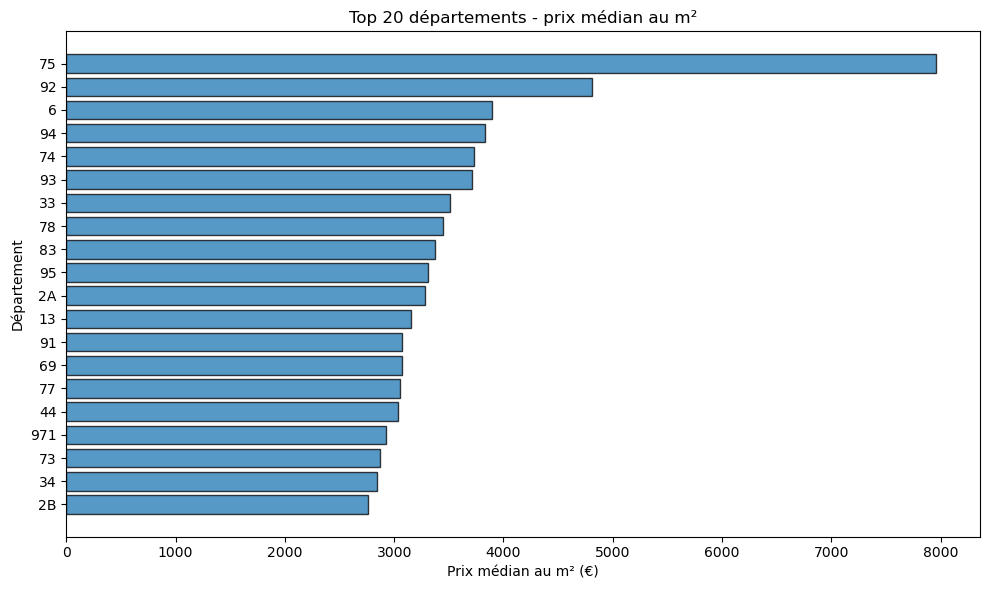

In [42]:
# Visualisation synthétique des départements les plus chers.
top_dep = agg_dep.sort_values("prix_m2_median", ascending=False).head(20).sort_values("prix_m2_median")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_dep["code_departement"].astype(str), top_dep["prix_m2_median"], edgecolor="black", alpha=0.75)

ax.set_title("Top 20 départements - prix médian au m²")
ax.set_xlabel("Prix médian au m² (€)")
ax.set_ylabel("Département")

plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Dispersion départementale</h3>
  <div style="color: #4b5563; font-size: 14px;">Analyse des départements aux prix médians les plus élevés Le département de Paris (75) se distingue nettement avec un prix médian au m² largement supérieur aux autres territoires, proche de 8 000 €/m². Les Hauts-de-Seine (92) occupent la deuxième position, confirmant la forte valorisation du marché immobilier francilien. Les départements d’Île-de-France dominent largement le classement, illustrant une forte concentration des prix élevés autour de la métropole parisienne. Plusieurs départements du littoral méditerranéen et des grandes métropoles régionales figurent également parmi les plus valorisés, notamment les Alpes-Maritimes (06), les Bouches-du-Rhône (13) et la Gironde (33). La présence de la Corse (2A et 2B) dans le classement traduit l’attractivité croissante des marchés insulaires et touristiques. Les écarts restent significatifs entre Paris et le reste du classement, mettant en évidence une polarisation importante du marché immobilier français. Cette hiérarchie territoriale reflète principalement l’effet combiné de la tension foncière, de l’attractivité économique et de la pression démographique..</div>
</div>

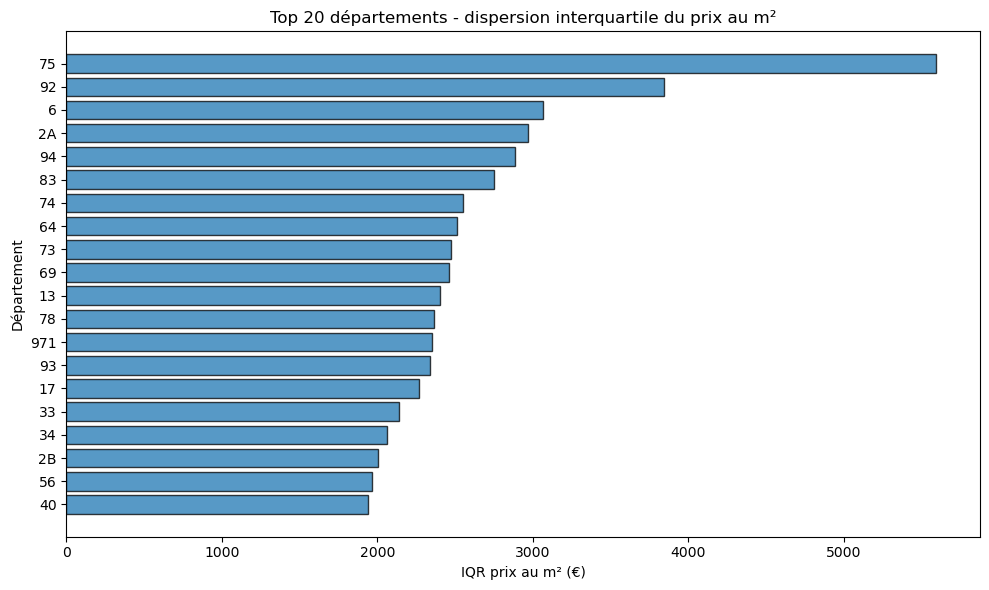

In [43]:
# Dispersion territoriale des prix.
# L'IQR mesure l'écart entre Q75 et Q25 : plus il est élevé, plus les prix locaux sont hétérogènes.
top_dispersion = agg_dep.sort_values("iqr_prix_m2", ascending=False).head(20).sort_values("iqr_prix_m2")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_dispersion["code_departement"].astype(str), top_dispersion["iqr_prix_m2"], edgecolor="black", alpha=0.75)

ax.set_title("Top 20 départements - dispersion interquartile du prix au m²")
ax.set_xlabel("IQR prix au m² (€)")
ax.set_ylabel("Département")

plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de la dispersion territoriale des prix</h3>
  <div style="color: #4b5563; font-size: 14px;">Analyse de la dispersion interquartile des prix au m² Paris (75) présente de loin la dispersion interquartile la plus élevée, traduisant une forte hétérogénéité des prix selon les arrondissements, les quartiers et le standing des biens. Les Hauts-de-Seine (92) et les Alpes-Maritimes (06) affichent également une dispersion importante, confirmant la coexistence de marchés très contrastés au sein de ces territoires. Les départements franciliens dominent largement le classement, ce qui reflète une segmentation marquée du marché immobilier autour des zones métropolitaines attractives. La présence des départements littoraux et touristiques, comme la Corse-du-Sud (2A) ou le Var (83), met en évidence l’impact des résidences secondaires et des biens haut de gamme sur la variabilité des prix. Une forte dispersion interquartile traduit généralement une diversité importante des biens, des localisations et des niveaux de revenus des acquéreurs. À l’inverse, les départements présentant une dispersion plus faible tendent à avoir un marché immobilier plus homogène et moins segmenté. Cette analyse complète l’étude des prix médians en mettant en évidence non seulement le niveau des prix, mais également leur degré de variabilité territoriale. Cette lecture confirme que la localisation territoriale ne joue pas seulement sur le niveau moyen des prix, mais aussi sur la structure et l’hétérogénéité du marché immobilier local.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Synthèse communale</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule construit une table territoriale au niveau commune et type de bien. Elle prépare une lecture plus fine du marché local : prix médian, dispersion, volume, surface et valeur.</div>
</div>

In [45]:
# Construction d'une synthèse territoriale par commune et type de bien.
# Cette table matérialise la dimension locale du marché pour les étapes aval.
agg_commune = (
    df_final[df_final["flag_prix_m2_valide"]]
    .groupby(["code_departement", "code_commune", "nom_commune", "type_bien"], dropna=False)
    .agg(
        nb_mutations=("id_mutation", "nunique"),
        prix_m2_med=("prix_m2", "median"),
        prix_m2_q1=("prix_m2", lambda x: x.quantile(0.25)),
        prix_m2_q3=("prix_m2", lambda x: x.quantile(0.75)),
        prix_m2_moy=("prix_m2", "mean"),
        surface_med=("surface_reference", "median"),
        surface_moy=("surface_reference", "mean"),
        valeur_med=("valeur_fonciere", "median"),
        valeur_moy=("valeur_fonciere", "mean"),
        part_avec_dependances=("avec_dependances", "mean"),
        ratio_bati_terrain_med=("ratio_bati_terrain", "median"),
        nb_pieces_med=("nb_pieces_total", "median")
    )
    .reset_index()
)

# L'écart interquartile fournit une mesure robuste de dispersion locale des prix.
agg_commune["prix_m2_amplitude"] = agg_commune["prix_m2_q3"] - agg_commune["prix_m2_q1"]

print("=== agg_commune (agrégation territoriale) ===")
print(f"Lignes : {len(agg_commune):,}")
print(f"Mutations agrégées : {agg_commune['nb_mutations'].sum():,}")
print("\n=== Top 20 communes par volume ===")
print(agg_commune.nlargest(20, "nb_mutations")[["code_commune", "nom_commune", "type_bien", "nb_mutations", "prix_m2_med"]])

=== agg_commune (agrégation territoriale) ===
Lignes : 44,437
Mutations agrégées : 3,929,102

=== Top 20 communes par volume ===
      code_commune               nom_commune    type_bien  nb_mutations  \
2659          6088                      Nice  Appartement         38099   
14779        31555                  Toulouse  Appartement         34715   
16336        34172               Montpellier  Appartement         21923   
20985        44109                    Nantes  Appartement         21491   
15409        33063                  Bordeaux  Appartement         17696   
35520        75115  Paris 15e Arrondissement  Appartement         15591   
35526        75118  Paris 18e Arrondissement  Appartement         15347   
16965        35238                    Rennes  Appartement         15058   
8676         21231                     Dijon  Appartement         14102   
18037        38185                  Grenoble  Appartement         13964   
27262        59350                     Lille  

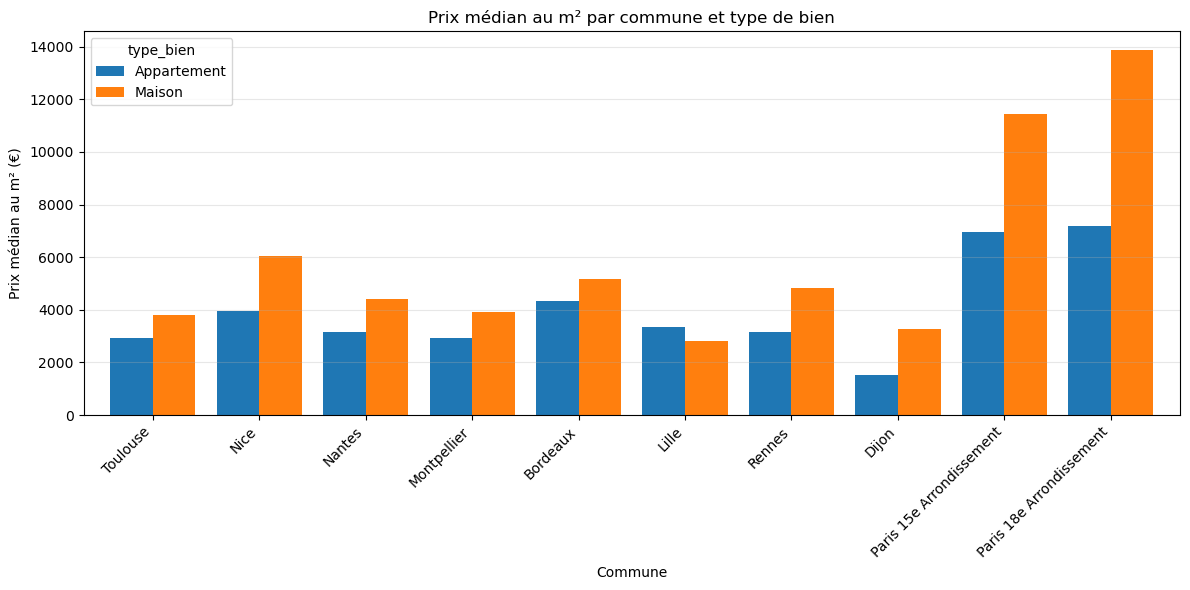

In [46]:
# Visualisation du prix médian par commune et par type de bien.
# L'usage de la médiane limite l'influence des observations extrêmes.
top_communes = df_final["nom_commune"].value_counts().head(10).index

plot_df = agg_commune[agg_commune["nom_commune"].isin(top_communes)].copy()
pivot_prix = (
    plot_df.pivot_table(
        index="nom_commune",
        columns="type_bien",
        values="prix_m2_med",
        aggfunc="first"
    )
    .reindex(top_communes)
)

ax = pivot_prix.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_xlabel("Commune")
ax.set_ylabel("Prix médian au m² (€)")
ax.set_title("Prix médian au m² par commune et type de bien")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des prix médians par commune et type de bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Analyse des prix médians au m² par commune et type de bien Les maisons affichent un prix médian au m² supérieur aux appartements dans la majorité des communes étudiées, avec des écarts particulièrement marqués à Paris. Les 15e et 18e arrondissements de Paris se distinguent nettement par des niveaux de prix très élevés, reflétant la forte tension du marché immobilier parisien. Le différentiel entre maisons et appartements est particulièrement important dans les secteurs les plus attractifs, où la rareté des maisons renforce leur valorisation. Bordeaux, Nice et Rennes présentent également des niveaux de prix soutenus, confirmant l’attractivité des grandes métropoles régionales. Lille constitue une exception notable, avec un prix médian au m² des appartements légèrement supérieur à celui des maisons. Dijon et Toulouse affichent des niveaux de prix plus modérés, traduisant des marchés immobiliers moins tendus. Les écarts observés entre communes soulignent l’influence déterminante de la localisation, de la pression foncière et de la dynamique démographique sur les valorisations immobilières. Le graphique confirme ainsi que les effets territoriaux et les typologies de biens interagissent fortement dans la formation des prix. Une lecture nationale agrégée ne suffit donc pas à décrire correctement les dynamiques locales du marché résidentiel.</div>
</div>

In [49]:
# Export de la base intermediaire destinee aux notebooks suivants du pipeline.
# Le schema est stabilise avant ecriture pour securiser la reutilisation.

df_export = df_final.copy()

# Conversion des identifiants geographiques en texte pour preserver leur semantique de code.
cols_codes = [
    "code_commune",
    "code_departement",
    "id_mutation"
]

for col in cols_codes:
    df_export[col] = df_export[col].astype("string")

# Conversion explicite des principales variables categorielles.
cols_categoricielles = [
    "type_bien",
    "nom_commune",
    ]

for col in cols_categoricielles:
    df_export[col] = df_export[col].astype("string")

df_export.to_parquet(OUTPUT_PATH, index=False)

print("\n" + "="*60)
print("  EXPORT EFFECTUE")
print("="*60)
print(f"Fichier     : {OUTPUT_PATH}")
print(f"Lignes      : {len(df_export):,}")
print(f"Colonnes    : {df_export.shape[1]}")
print(f"Poids       : {OUTPUT_PATH.stat().st_size / (1024**2):.1f} MB")

print("\n=== Composition finale ===")
print("Types de biens :")

for bien in df_export["type_bien"].value_counts().index:
    nb = (df_export["type_bien"] == bien).sum()
    pct = (df_export["type_bien"] == bien).mean() * 100
    print(f"  {bien:15s} : {nb:7,d} ({pct:5.1f}%)")

print(f"\nQualite globale : {df_export['flag_qualite_globale'].mean()*100:.1f}%")


  EXPORT EFFECTUE
Fichier     : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_dvf_base_eco_intermediaire.parquet
Lignes      : 4,019,581
Colonnes    : 51
Poids       : 219.9 MB

=== Composition finale ===
Types de biens :
  Maison          : 2,117,308 ( 52.7%)
  Appartement     : 1,902,273 ( 47.3%)

Qualite globale : 97.7%


In [50]:
# Contrôle final du schéma exporté : type, nullité et stabilité des variables.
print("\n=== Colonnes du dataset final ===")
for i, col in enumerate(sorted(df_final.columns), 1):
    dtype = str(df_final[col].dtype)
    nulls = df_final[col].isna().sum()
    pct_nulls = df_final[col].isna().mean() * 100
    print(f"{i:2d}. {col:40s} | {dtype:15s} | {nulls:7,d} ({pct_nulls:5.1f}%)")


=== Colonnes du dataset final ===
 1. avec_dependances                         | bool            |       0 (  0.0%)
 2. categorie_logement                       | object          |       0 (  0.0%)
 3. code_commune                             | object          |       0 (  0.0%)
 4. code_departement                         | object          |       0 (  0.0%)
 5. date_mutation                            | datetime64[ns]  |       0 (  0.0%)
 6. flag_prix_m2_valide                      | bool            |       0 (  0.0%)
 7. flag_qualite_globale                     | bool            |       0 (  0.0%)
 8. flag_surface_reference_valide            | bool            |       0 (  0.0%)
 9. flag_valeur_valide                       | bool            |       0 (  0.0%)
10. has_bati                                 | bool            |       0 (  0.0%)
11. has_dependance                           | bool            |       0 (  0.0%)
12. has_imm_special                          | bool            

In [51]:
# Vérification de l'horizon temporel couvert par les données DVF

df_final["date_mutation"] = pd.to_datetime(df_final["date_mutation"], errors="coerce")

print("=== Horizon temporel DVF ===")
print(f"Date minimale : {df_final['date_mutation'].min().date()}")
print(f"Date maximale : {df_final['date_mutation'].max().date()}")
print(f"Nombre d'années couvertes : {df_final['date_mutation'].dt.year.nunique()}")

display(
    df_final["date_mutation"]
    .dt.year
    .value_counts()
    .sort_index()
    .to_frame("nb_mutations")
)

=== Horizon temporel DVF ===
Date minimale : 2021-01-01
Date maximale : 2025-12-31
Nombre d'années couvertes : 5


,nb_mutations
date_mutation,
2021,956332
2022,922156
2023,732346
2024,662191
2025,746556


In [52]:
# Création des variables temporelles pour l'analyse

df_final["annee_mutation"] = df_final["date_mutation"].dt.year
df_final["trimestre_mutation"] = df_final["date_mutation"].dt.to_period("Q").astype(str)

print("✓ Variables temporelles créées")
display(
    df_final[["date_mutation", "annee_mutation", "trimestre_mutation"]].head()
)

✓ Variables temporelles créées


,date_mutation,annee_mutation,trimestre_mutation
0,2021-01-05,2021,2021Q1
1,2021-01-08,2021,2021Q1
3,2021-04-01,2021,2021Q2
4,2021-03-03,2021,2021Q1
7,2021-12-10,2021,2021Q4


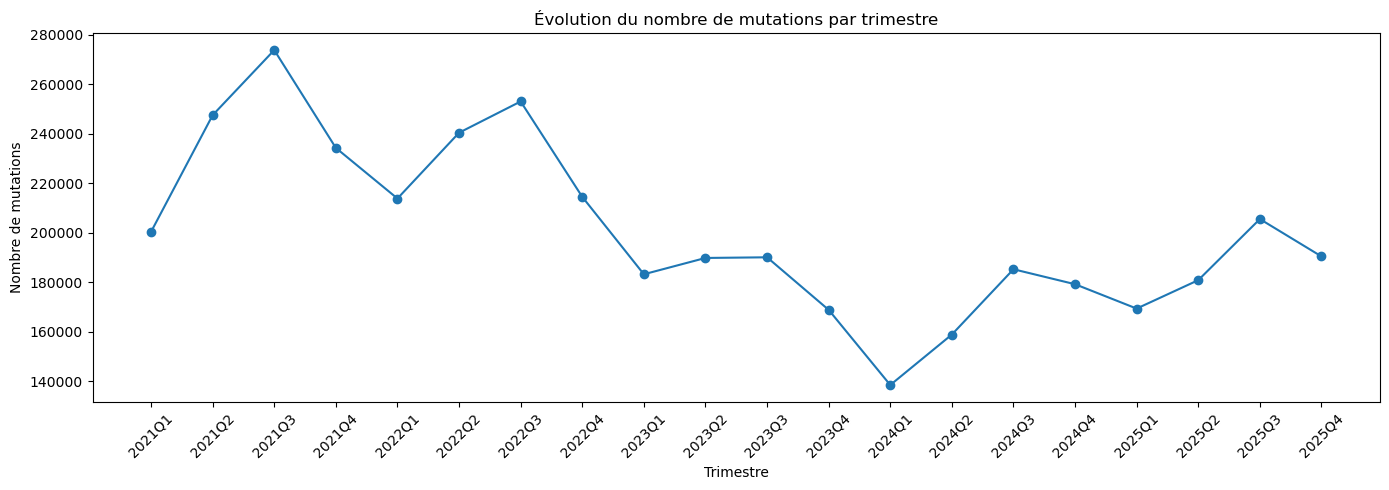

In [53]:
# Évolution du nombre de mutations par trimestre

evolution_trim = (
    df_final
    .groupby("trimestre_mutation")
    .size()
    .reset_index(name="nb_mutations")
)

plt.figure(figsize=(14, 5))

plt.plot(
    evolution_trim["trimestre_mutation"],
    evolution_trim["nb_mutations"],
    marker="o"
)

plt.title("Évolution du nombre de mutations par trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Nombre de mutations")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de l’évolution du volume de mutations</h3>
  <div style="color: #4b5563; font-size: 14px;">Analyse de l’évolution du nombre de mutations par trimestre Le volume de mutations immobilières atteint un pic en 2021, avec un maximum observé au troisième trimestre, traduisant une forte dynamique post-crise sanitaire. À partir de 2022, le marché entre progressivement dans une phase de ralentissement, marquée par une diminution continue du nombre de transactions. Le recul devient particulièrement visible en 2023 et début 2024, période durant laquelle les volumes atteignent leurs niveaux les plus bas de la série. Cette contraction du marché peut être associée à la hausse des taux d’intérêt, au durcissement des conditions de crédit et au ralentissement du pouvoir d’achat immobilier. Une reprise modérée apparaît ensuite à partir du second semestre 2024 et se confirme en 2025, sans toutefois retrouver les niveaux records observés en 2021. Les variations trimestrielles mettent également en évidence une certaine saisonnalité du marché immobilier, avec des volumes souvent plus élevés au printemps et en été. L’évolution globale traduit un passage d’un marché très dynamique vers une phase de normalisation et d’ajustement conjoncturel. Cette évolution confirme que la temporalité constitue un facteur explicatif important du marché immobilier. Les volumes de transactions ne sont pas stables dans le temps et peuvent refléter des changements macroéconomiques, financiers ou réglementaires influençant directement l’activité du marché résidentiel.</div>
</div>

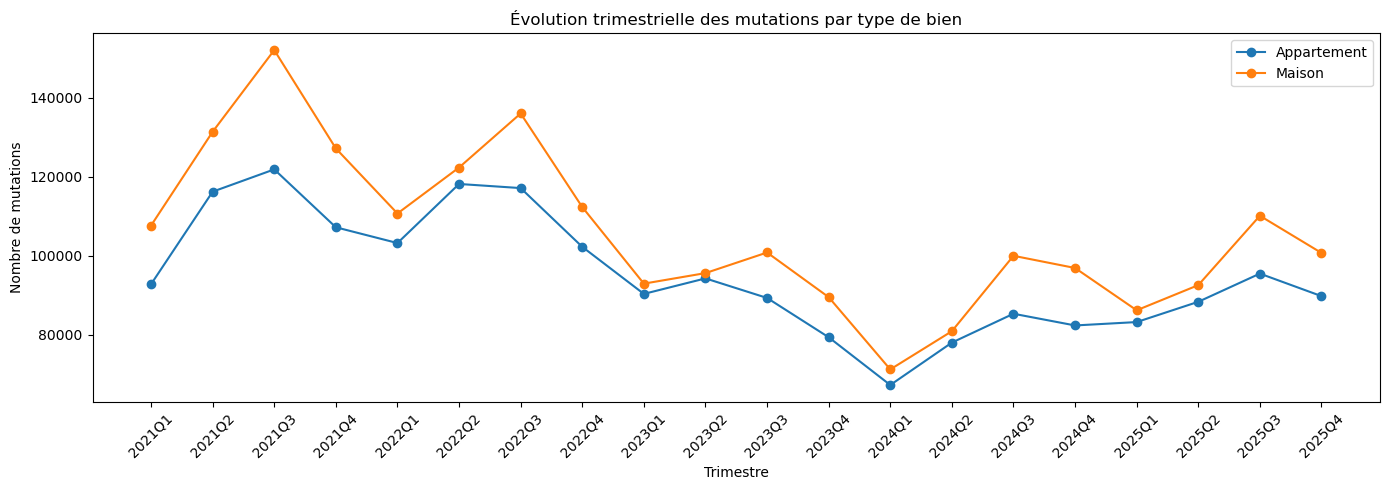

In [54]:
# Évolution trimestrielle des mutations par type de bien

evolution_type_trim = (
    df_final
    .groupby(["trimestre_mutation", "type_bien"])
    .size()
    .reset_index(name="nb_mutations")
)

plt.figure(figsize=(14, 5))

for bien in evolution_type_trim["type_bien"].dropna().unique():
    subset = evolution_type_trim[evolution_type_trim["type_bien"] == bien]
    plt.plot(
        subset["trimestre_mutation"],
        subset["nb_mutations"],
        marker="o",
        label=bien
    )

plt.title("Évolution trimestrielle des mutations par type de bien")
plt.xlabel("Trimestre")
plt.ylabel("Nombre de mutations")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de l’évolution trimestrielle par type de bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Analyse de l’évolution trimestrielle des mutations par type de bien Les maisons enregistrent systématiquement un volume de mutations supérieur à celui des appartements sur l’ensemble de la période observée. Les deux segments suivent néanmoins des dynamiques très proches, avec un pic d’activité atteint en 2021 puis un ralentissement progressif à partir de 2022. La baisse des transactions devient particulièrement marquée entre 2023 et début 2024, période correspondant au durcissement des conditions de financement immobilier. Les appartements apparaissent légèrement plus sensibles aux phases de contraction du marché, avec un recul plus prononcé des volumes sur certaines périodes. Une reprise modérée des mutations est observable à partir du second semestre 2024, aussi bien pour les maisons que pour les appartements. Les maisons conservent un niveau d’activité relativement soutenu en 2025, traduisant une demande toujours présente pour les biens individuels malgré le ralentissement du marché. Les évolutions parallèles des deux courbes confirment l’influence des facteurs macroéconomiques sur l’ensemble du marché résidentiel, indépendamment du type de bien. Cette lecture confirme que la temporalité influence différemment les segments immobiliers et qu’une analyse séparée des appartements et des maisons apporte une compréhension plus fine des évolutions du marché résidentiel.</div>
</div>

In [55]:
# Export d'un echantillon CSV pour inspection rapide hors environnement notebook.
cols_export = [
    "id_mutation", "date_mutation", "code_departement", "nom_commune",
    "type_bien", "sous_categorie_logement",
    "valeur_fonciere", "surface_reference", "surface_terrain_reference",
    "prix_m2", "nb_pieces_total", "avec_dependances",
    "flag_qualite_globale"
]

df_final[cols_export].head(1000).to_csv(SAMPLE_OUTPUT_PATH, index=False)
print(f"\n✓ Aperçu CSV exporté : {SAMPLE_OUTPUT_PATH}")


✓ Aperçu CSV exporté : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_dvf_base_eco_intermediaire_sample.csv
